# Objectif 

Date de création : 06/04/2026

Illustration de la sensibilité de la distance $\theta$ utilisé à l'aide d'un exemple très simple dans un guide d'onde idéal. 

## Cadre de l'étude 

* Antenne HLA de deux capteurs, immersion fixe $z_a = 50$ m.
* Source d'immersion fixe $z_s = 5$ m, distance au capteur de référence r variable. 
* Environnement : guide d'onde idéal (fond parfaitement solide), profondeur $D_w = 100$ m. 

## Approche 

L'immersion de la source est fixée à $z_s = 5$ m, la distance $r$ de la source au capteur de référence (capteur 1) varie dans un intervalle $I_r$, 

$$ I_r = [r_{ref} - \Delta_r, r_{ref} + \Delta_r] $$ 

** Définition du RTF 
$$
    \mathbf{\Pi_{12}} \overset{\Delta}{=}
    \left [ \frac{H_{2}(k_1)}{H_{1}(k_1)}, \, \frac{H_{2}(k_2)}{H_{1}(k_2)} \, ..., \, \frac{H_{2}(k_D)}{H_{1}(k_D)} \right]^T \in \mathbb{C}^D
$$

On s'intéresse à la distance entre le RTF $\mathbf{\Pi_{12}}(r)$ associé à la position $r$ de la source et le RTF de référence $\mathbf{\Pi_{12}}^{ref} = \mathbf{\Pi_{12}}({r = r_{ref}})$ associé associé à la position de référence $r_{ref}$. 

## Rappel formulation modale 

On pose 
$$
    Q =  \frac{e^{i3\pi/4}}{\rho(z_s) \sqrt{8 \pi}}
$$

et

$$
    A_m(z) = \Psi_m(z_{s}) \Psi_m(z) \frac{1}{\sqrt{k_{rm}}}
$$

La fonction de transfert du guide d'onde s'écrit,

$$
    H(f, r, z) = \frac{Q}{\sqrt{r}} \sum_{m=1}^{\infty} A_m(z) e^{-ik_{rm}
    r}
$$

En particulier, la fonction de transfert du canal de propagation associée au récepteur $j$ est :

$$
    H_{j} = \frac{Q}{\sqrt{r_j}} \sum_{m=1}**{\infty} A_m(z_j) e^{-ik_{rm}
    r_{j}}
$$

on s'intéresse au vecteur de RTF défini par

$$
    \mathbf{\Pi} \overset{\Delta}{=}
    \left [ \frac{H_{1}}{H_{1}} \, \frac{H_{2}}{H_{1}} \, \dots \, \frac{H_{M}}{H_{1}} \right ]^T
    = \frac{1}{H_{1}} \mathbf{H}
$$

En particulier, il s'agira d'étudier le comportement d'une composante du vecteur $\mathbf{\Pi}$,

$$
    \Pi_j = \frac{H_j}{H_1}, \quad j \in [1, J]
$$

**Conditions aux limites (cas parfaitement solide -> perfectly_rigid) **

Pression nulle en surface et au fond :
$$
p(r, z=0) = 0 \quad \text{et} \quad \frac{\partial p(r, z)}{\partial z} \rvert_{z=D} = 0 
$$

et les fonctions modales s'écrivent 

$$
\Psi_m(z) = \sqrt{\frac{2 \rho}{D}} \sin(k_{zm} z)
$$

Les fonctions $\Psi_m$ sont les fonctions propres associées aux valeurs propres $k_{rm}$,

$$
    k_{rm} = \sqrt{ k^2 - k_{zm}^2}
$$

avec, 

$$ 
k_{zm} =  (m - \frac{1}{2}) \frac{\pi}{D}, \quad m \in \mathbb{N}^{*} .
$$           

In [1]:
# %matplotlib ipympl

import os
import sys
import numpy as np
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks


sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from misc import mult_along_axis
from propa.ideal_waveguide import (
    kr,
    psi,
    psi_normalised,
    h,
    field,
    plot_tl,
    nb_propagating_modes,
    intensity,
    intensity_1,
)

from propa.rtf.rtf_utils import D_hermitian_angle_fast

import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure, color

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility", "ideal_wg")

In [3]:
# Compute the dataset
def calc_pi_12(f, r_grid1, r_grid2, z_source, z_antenna, depth, bottom_bc):

    ff, rr, zz, p_field1 = field(
        f=f,
        z_src=z_antenna,    # Reciprocity: source is at antenna depth
        z=z_source,           # Reciprocity: receiver is at source depth
        r=r_grid1,
        depth=depth,
        bottom_bc=bottom_bc,
    )
    ff, _, _, p_field2 = field(
        f=f,
        z_src=z_antenna,    # Reciprocity: source is at antenna depth
        z=z_source,           # Reciprocity: receiver is at source depth
        r=r_grid2,                                    
        depth=depth,
        bottom_bc=bottom_bc,
    )
    p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
    p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
    pi_12 = p_field2 / p_field1

    return ff, rr, zz, p_field1, p_field2, pi_12

In [16]:
def compute_rtf_dataset(f, r_grid1, r_grid2, z_s, z_a, waveguide_depth, bottom_bc, r_ref, d12):

    # Compute RTF on the whole grid for a different number of modes
    ff, rr, zz, p_field1, p_field2, pi_12 = calc_pi_12(
        f=f,
        r_grid1=r_grid1,
        r_grid2=r_grid2,
        z_source=z_s,
        z_antenna=z_a,
        depth=waveguide_depth,
        bottom_bc=bottom_bc,
    )
    # Shape pi_12 = (nf, 1, nr)

    # Compute RTF at reference range
    ff, rr_ref, zz, p_field1_ref, p_field2_ref, pi_12_ref = calc_pi_12(
        f=f,
        r_grid1=np.array([r_ref]),
        r_grid2=np.array([r_ref + d12]),
        z_source=z_s,
        z_antenna=z_a,
        depth=waveguide_depth,
        bottom_bc=bottom_bc,
    )
    # Shape pi_12_ref = (nf, 1, 1)

    n_propa_modes_vs_f = np.array(
        [
            nb_propagating_modes(
                f=fi, c=g.c0, depth=waveguide_depth, bottom_bc=bottom_bc
            )
            for fi in ff
        ]
    )

    # Add one dimension to fit the usual shape of RTF vectors (array of one for H_ref/H_ref)
    # Target shape is (n_rcv, nf, nr)
    p_field1 = p_field1.squeeze(axis=1)  # (nf, nr)
    p_field2 = p_field2.squeeze(axis=1)  # (nf, nr)
    pi_12 = pi_12.squeeze(axis=1)  # (nf, nr)
    pi_11 = np.ones_like(pi_12).astype(np.complex64)
    pi_12_full = np.array([pi_11, pi_12])  # (nrcv, nf, nr)

    # Same thing for pi_ref -> (nrcv, nf)
    pi_12_ref = pi_12_ref.squeeze(axis=(1, 2))
    pi_11_ref = np.ones_like(pi_12_ref).astype(np.complex64)
    pi_12_ref_full = np.array([pi_11_ref, pi_12_ref])

    ds = xr.Dataset(
        data_vars=dict(
            H1=(["f", "r"], p_field1),
            H2=(["f", "r"], p_field2),
            data=(["h_index", "f", "r"], pi_12_full),
            phase=(["h_index", "f", "r"], np.angle(pi_12_full)),
            module=(["h_index", "f", "r"], np.abs(pi_12_full)),
            data_ref=(["h_index", "f"], pi_12_ref_full),
            nb_modes=(["f"], n_propa_modes_vs_f),
        ),
        coords=dict(
            f=ff,
            r=rr.squeeze(),
            h_index=[1, 2],
        ),
        attrs=dict(
            description=f"RTF dataset for an ideal waveguide. The antenna is composed of two receivers separated by d12={d12}m. The source is at z_s={z_s}m and the antenna at z_a={z_a}m in a waveguide of depth {waveguide_depth}m.",
            bottom_bc=bottom_bc,
            waveguide_depth=waveguide_depth,
            z_s=z_s,
            z_a=z_a,
            r_ref=r_ref,
            d12=d12,
            h_index_ref=1,
        ),
    )

    # Add usefull attrs
    ds.f.attrs = {"unit": "Hz", "long_name": "Frequency"}
    ds.r.attrs = {"unit": "m", "long_name": "Range"}

    print("Dataset computed")

    return ds

In [50]:
def plot_tls(ds, fmin, fmax, root_fig):
    # Plot TL at fmin, fmax and center frequency
    lfig = LargeFigure(legend_fontsize=12)
    frequencies_to_plot = [fmin, (fmin + fmax) / 2, fmax]
    for freq in frequencies_to_plot:
        # idx_freq = np.argmin(np.abs(ff - freq))

        # tl1 = -20 * np.log10(4 * np.pi * np.abs(p_field1[idx_freq, :]) + 1e-20)
        # tl2 = -20 * np.log10(4 * np.pi * np.abs(p_field2[idx_freq, :]) + 1e-20)

        tl1 = -20 * np.log10(
            4 * np.pi * np.abs(ds.H1.sel(f=freq, method="nearest")) + 1e-20
        )
        tl2 = -20 * np.log10(
            4 * np.pi * np.abs(ds.H2.sel(f=freq, method="nearest")) + 1e-20
        )

        tl1.plot(label=f"Receiver 1 at {freq} Hz", linestyle="-")
        tl2.plot(label=f"Receiver 2 at {freq} Hz", linestyle="--")
    plt.legend()
    plt.gca().invert_yaxis()
    plt.title("")
    plt.ylabel("TL [dB]")

    fname = f"TL_fmin_fmax_fmid.png"
    fpath = os.path.join(root_fig, fname)
    plt.savefig(fpath)

In [51]:
def plot_pi_fr_plan(ds, root_fig, rmin=None, rmax=None):
    lfig = LargeFigure(legend_fontsize=14, size=(16, 8))
    fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True)
    ax1, ax2, ax3 = axs

    rtf_mod = 10 * np.log10(ds.module)

    rtf_mod.sel(h_index=2).plot(
        x="f",
        cmap="magma",
        vmin=np.percentile(rtf_mod, 5),
        vmax=np.percentile(rtf_mod, 95),
        ax=ax1,
        cbar_kwargs={"label": r"$\lvert \Pi\rvert$ [dB]"},
    )

    rtf_phase = ds.phase
    rtf_phase.sel(h_index=2).plot(
        x="f",
        cmap="bwr",
        vmin=np.percentile(rtf_phase, 5),
        vmax=np.percentile(rtf_phase, 95),
        ax=ax2,
        cbar_kwargs={"label": r"$\Phi$ [rad]"},
    )

    ds.nb_modes.plot(ax=ax3)
    ax3.set_ylabel("Modes")

    ax1.set_title("")
    ax2.set_title("")
    ax3.set_title("")

    if rmin is not None and rmax is not None:

        ax1.set_ylim([rmin, rmax])
        ax2.set_ylim([rmin, rmax])
        fname = f"rtf_module_phase_f_r_plan_zoom_rmin{rmin}_rmax{rmax}.png"
    
    else:
        fname = "rtf_module_phase_f_r_plan.png"

    fpath = os.path.join(root_fig, fname)
    plt.savefig(fpath)
    # plt.xscale("log")

In [71]:
def get_theta(ds):
    rtf = ds.data.values[..., np.newaxis]

    # Compute dist
    dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": False, "apply_median": True}
    theta = D_hermitian_angle_fast(
        rtf_ref=ds.data_ref.values,
        rtf=rtf,
        **dist_kwargs,
    )

    theta_mod = D_hermitian_angle_fast(
        rtf_ref=np.abs(ds.data_ref.values),
        rtf=np.abs(rtf),
        **dist_kwargs,
    )

    theta_phi = D_hermitian_angle_fast(
        rtf_ref=np.angle(ds.data_ref.values),
        rtf=np.angle(rtf),
        **dist_kwargs,
    )

    return theta, theta_mod, theta_phi

def plot_theta(r_grid_km, theta, theta_mod, root_fig, rmin=None, rmax=None):

    plt.figure()
    plt.plot(r_grid_km, theta, label=r"$\theta$")
    plt.plot(r_grid_km, theta_mod, label=r"$\theta_{\text{mod}}$")

    plt.xlabel("Range [km]")
    plt.ylabel(r"$\theta$ [°]")
    plt.legend()

    if rmin is not None and rmax is not None:
        plt.xlim([rmin, rmax])
        fname = f"theta_vs_r_zoom_rmin{rmin}_rmax{rmax}.png"

    else:
        fname = "theta_vs_r.png"

    fpath = os.path.join(root_fig, fname)
    plt.savefig(fpath)

In [72]:
def plot_pi_close_ref_pos(ds, theta, root_fig):

    # Plot module and phase at close pos
    theta_thresholds = [20, 30, 40]
    r = ds.r.values
    r_minus_rref = r- ds.r_ref
    dr_pos_idx = r_minus_rref >= 0
    r_pos = r[dr_pos_idx]
    theta_r_pos = theta[dr_pos_idx]

    lfig = LargeFigure(legend_fontsize=14, size=(16, 10))
    fig, axs = plt.subplots(nrows=3, ncols=1, sharex=False)
    ax1, ax2, ax3 = axs

    ax1.plot(r, theta, color="k")
    ax1.set_ylabel(r"$\theta$ [°]")

    for i, th in enumerate(theta_thresholds):
        idx = np.where(theta_r_pos >= th)[0][0]
        r_th = r_pos[idx]

        rtf_mod_at_th_pos = ds.module.sel(h_index=2).sel(r=r_th, method="nearest")
        rtf_mod_at_th_pos.plot(ax=ax2, label=f"r = {rtf_mod_at_th_pos.r.values:.1f}m", color=color(i))

        rtf_phase_at_th_pos = ds.phase.sel(h_index=2).sel(r=r_th, method="nearest")
        rtf_phase_at_th_pos.plot(ax=ax3, label=f"r = {rtf_mod_at_th_pos.r.values:.1f}m", color=color(i))

        ax1.scatter(
            r_th,
            theta_r_pos[idx],
            color=color(i),
            label=r"$\theta$ = " + str(th) + f"° (r = {rtf_mod_at_th_pos.r.values:.1f}m)",
        )

    ax2.set_yscale("log")
    ax2.set_ylabel(r"$\lvert \Pi \rvert $")

    ax3.set_ylabel(r"$\Phi$")

    ax1.set_title("")
    ax2.set_title("")
    ax3.set_title("")
    ax1.legend()
    ax2.legend()
    ax3.legend()


    fname = "rtf_at_selected_theta.png"
    fpath = os.path.join(root_fig, fname)
    plt.savefig(fpath)


In [73]:
def run_full_study(
    bottom_bc="perfectly_rigid",
    waveguide_depth=1000,
    d_inter_rcv=1000,
    z_rcv=999,
    src_ref_range=2 * 1e3,
    z_src=5, 
    nrgrid=1001,
    delta_r=1 * 1e3,
    fmin=10,
    fmax=20,
    nfgrid=500,
):
    # Compute grid
    rmin = src_ref_range - delta_r
    rmax = src_ref_range + delta_r
    r_grid = np.linspace(rmin, rmax, nrgrid)
    r_grid_km = r_grid / 1e3
    r_grid1 = r_grid    # Range from source to receiver 1
    r_grid2 = r_grid + d_inter_rcv  # Range from source to receiver 2

    f = np.linspace(fmin, fmax, nfgrid)  # Frequency vector

    n_propagating_modes_fmin = nb_propagating_modes(
        f=fmin, c=g.c0, depth=waveguide_depth, bottom_bc=bottom_bc
    )
    print(f"Number of propagating modes at fmin = {fmin} Hz : {n_propagating_modes_fmin}")
    n_propagating_modes_fmax = nb_propagating_modes(
        f=fmax, c=g.c0, depth=waveguide_depth, bottom_bc=bottom_bc
    )
    print(f"Number of propagating modes at fmax = {fmax} Hz : {n_propagating_modes_fmax}")

    # Compute RTF dataset
    ds = compute_rtf_dataset(f=f, r_grid1=r_grid1, r_grid2=r_grid2, z_s=z_src, z_a=z_rcv, waveguide_depth=waveguide_depth, bottom_bc=bottom_bc, r_ref=src_ref_range, d12=d_inter_rcv)

    # Define root to store img
    root_fig = os.path.join(
        sensibility_img_folder,
        f"Dw_{waveguide_depth:.1f}m_fmin_{fmin:.1f}Hz_fmax_{fmax:.1f}Hz",
    )
    os.makedirs(root_fig, exist_ok=True)

    # Plot TL
    plot_tls(ds, fmin=fmin, fmax=fmax, root_fig=root_fig)

    # Plot Pi in f, r plan
    plot_pi_fr_plan(ds, root_fig=root_fig)

    # Plot zoom
    dr_zoom = 50
    plot_pi_fr_plan(
        ds,
        rmin=src_ref_range - dr_zoom,
        rmax=src_ref_range + dr_zoom,
        root_fig=root_fig,
    )

    # Compute theta
    theta, theta_mod, theta_phi = get_theta(ds)

    # Plot theta vs range
    plot_theta(r_grid_km, theta, theta_mod, root_fig=root_fig)

    # Plot zoom
    plot_theta(
        r_grid_km,
        theta,
        theta_mod,
        rmin=(src_ref_range - dr_zoom) * 1e-3,
        rmax=(src_ref_range + dr_zoom) * 1e-3,
        root_fig=root_fig,
    )

    plot_pi_close_ref_pos(ds, theta, root_fig=root_fig)

Number of propagating modes at fmin = 10 Hz : 13
Number of propagating modes at fmax = 20 Hz : 27
Dataset computed


C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_utils.py:268: RuntimeWarning: invalid value encountered in divide
  cos_angle = np.clip(inner_prod / (norm_ref * norm_rtf), -1.0, 1.0)


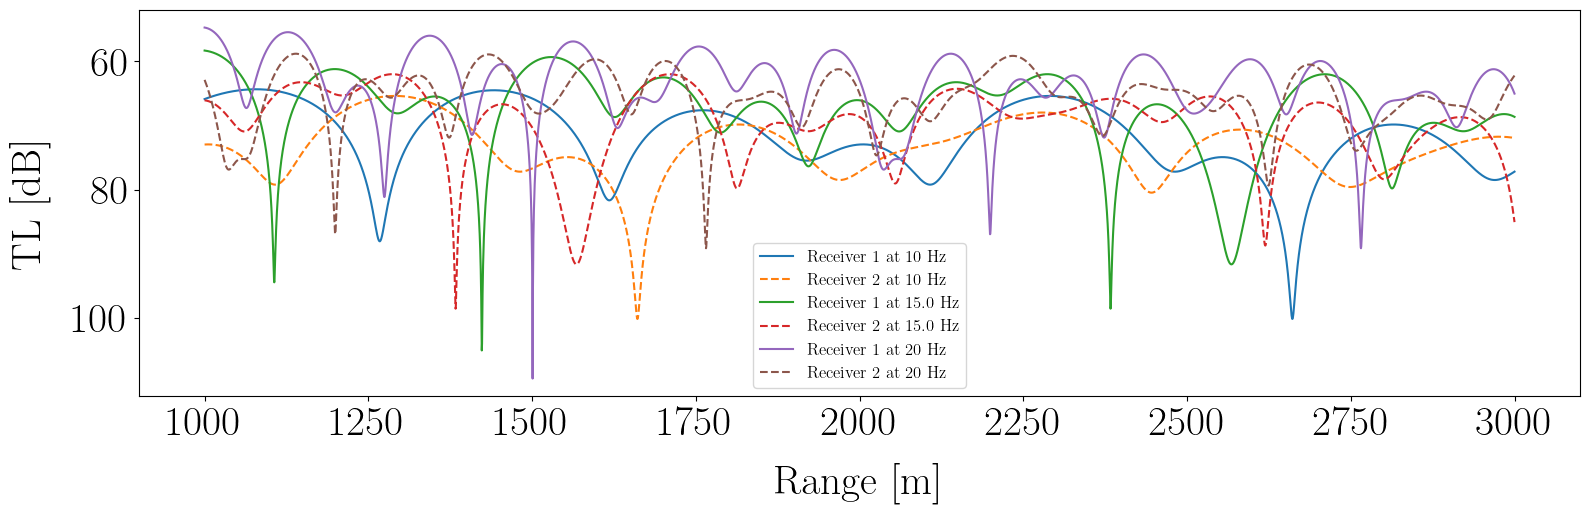

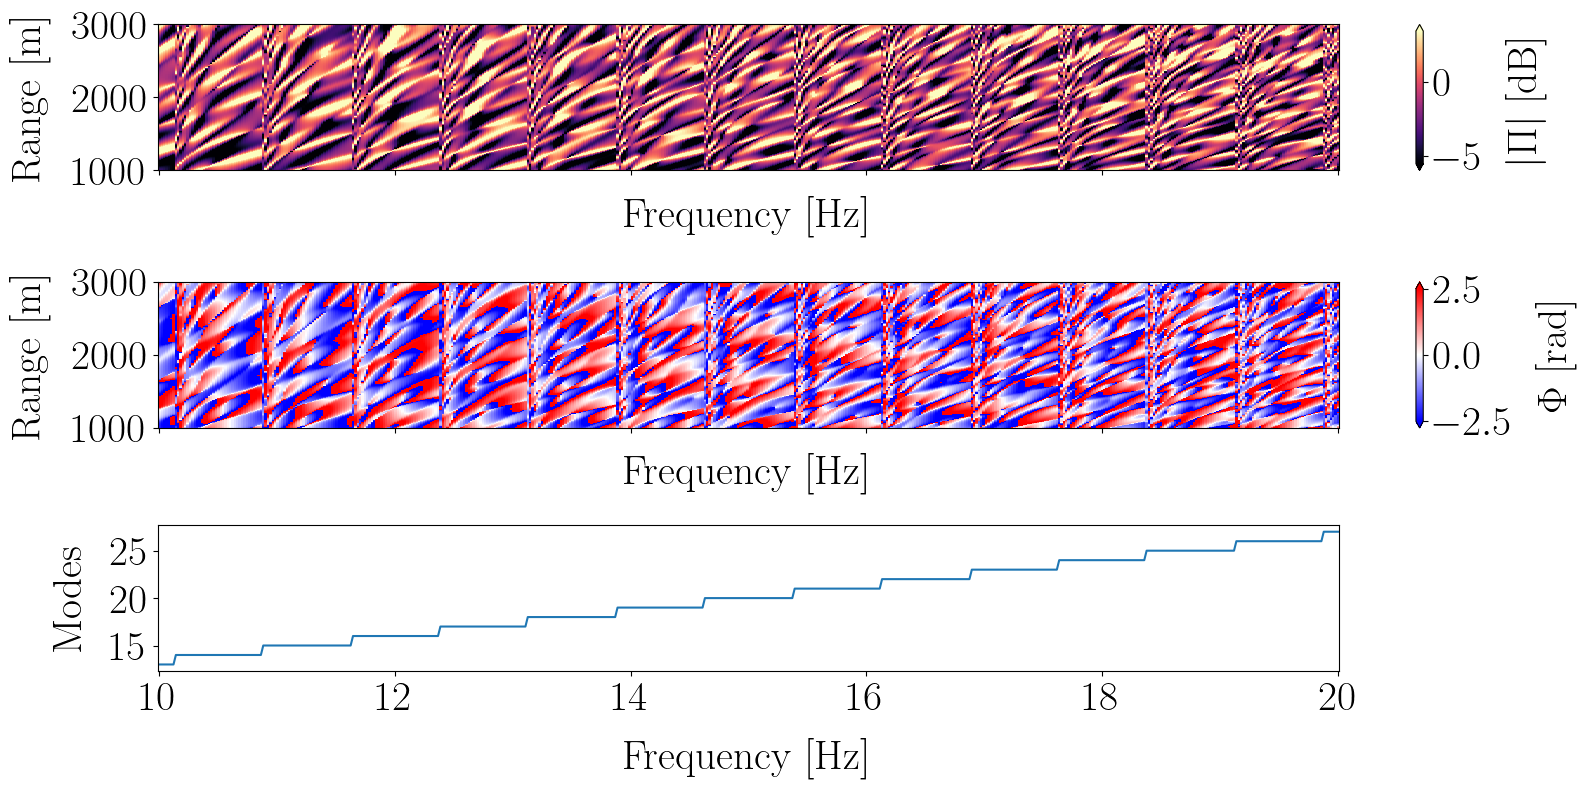

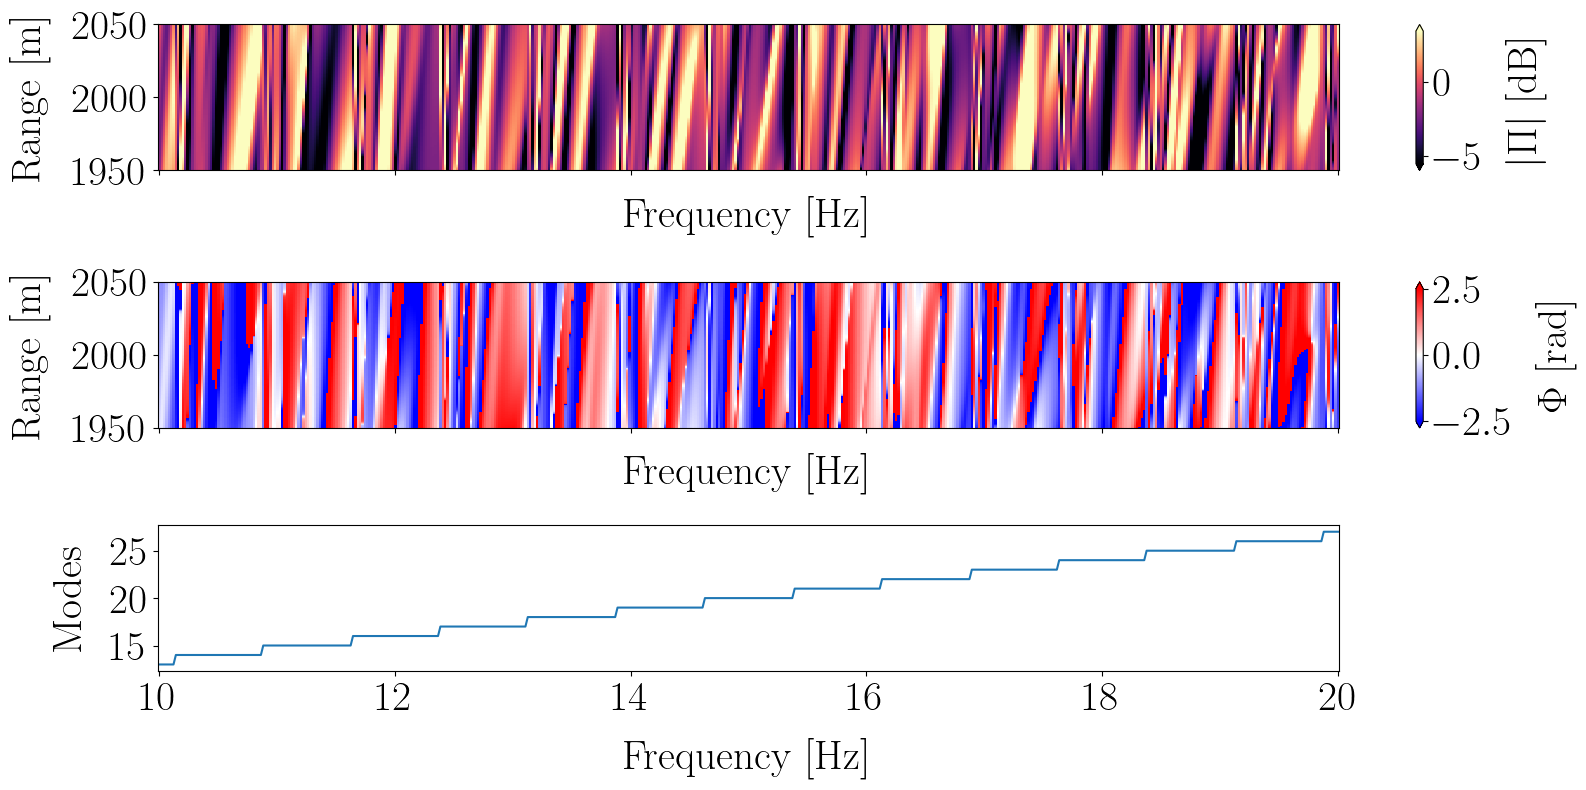

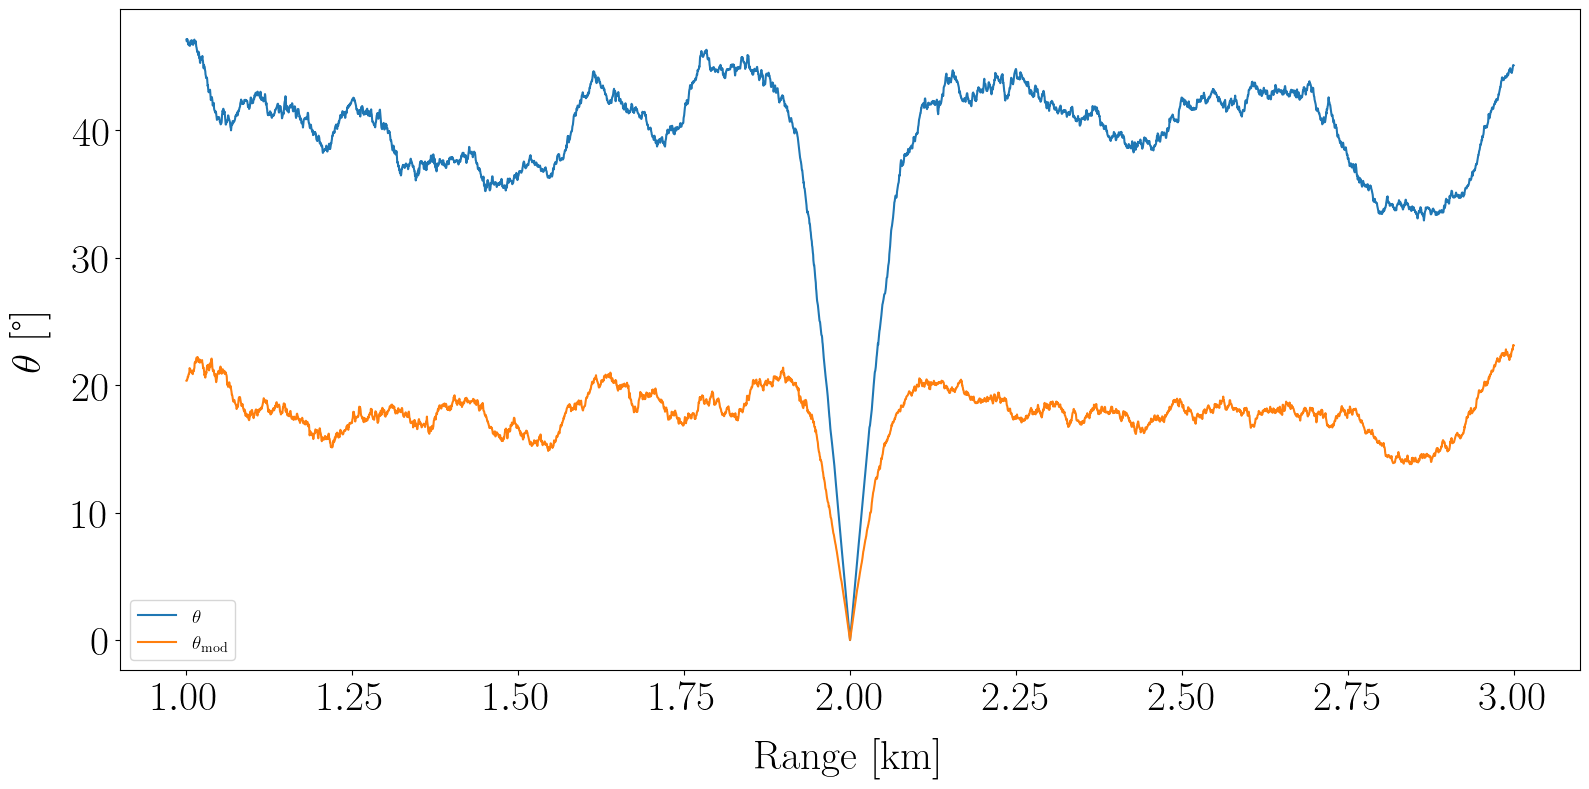

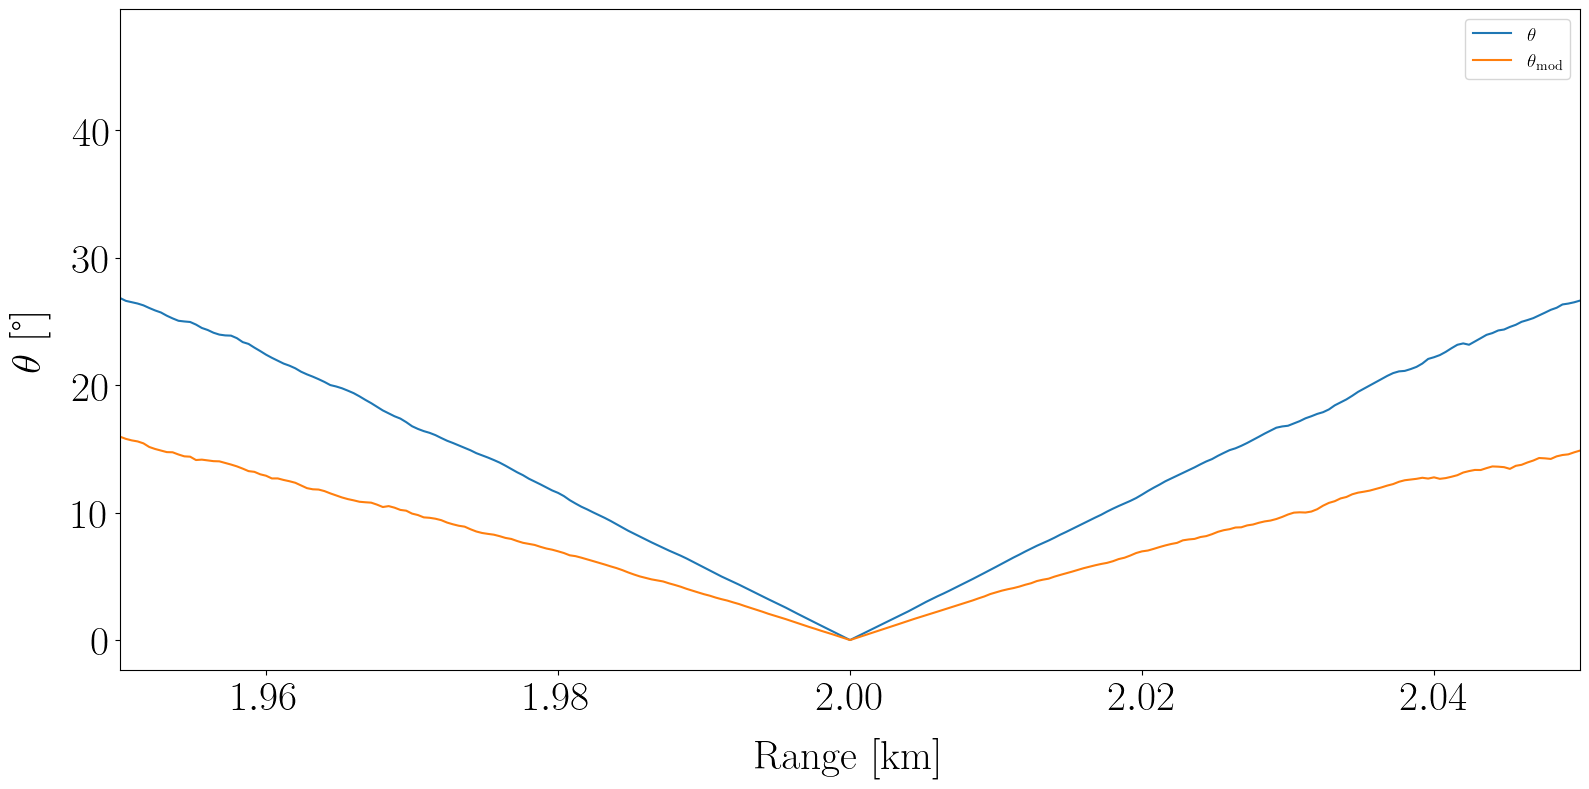

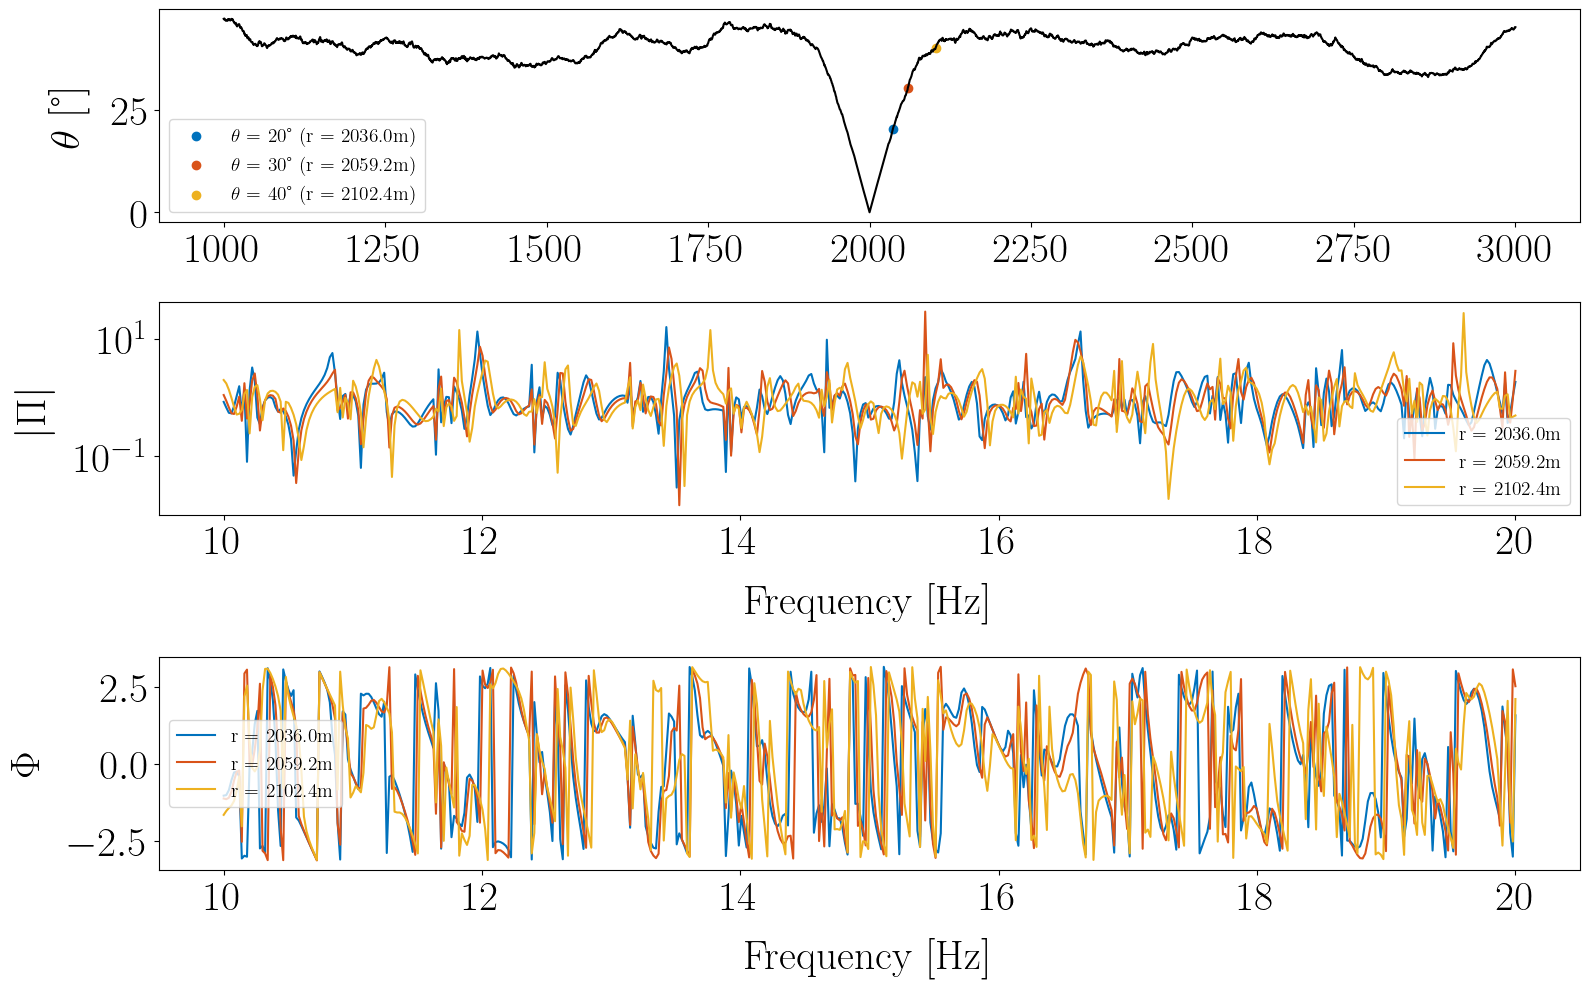

In [74]:
run_full_study(
    bottom_bc="perfectly_rigid",
    waveguide_depth=1000,
    d_inter_rcv=1000,
    z_rcv=999,
    src_ref_range=2 * 1e3,
    z_src=5,
    nrgrid=5001,
    delta_r=1 * 1e3,
    fmin=10,
    fmax=20,
    nfgrid=500,
)

Number of propagating modes at fmin = 100 Hz : 133
Number of propagating modes at fmax = 200 Hz : 267
Dataset computed


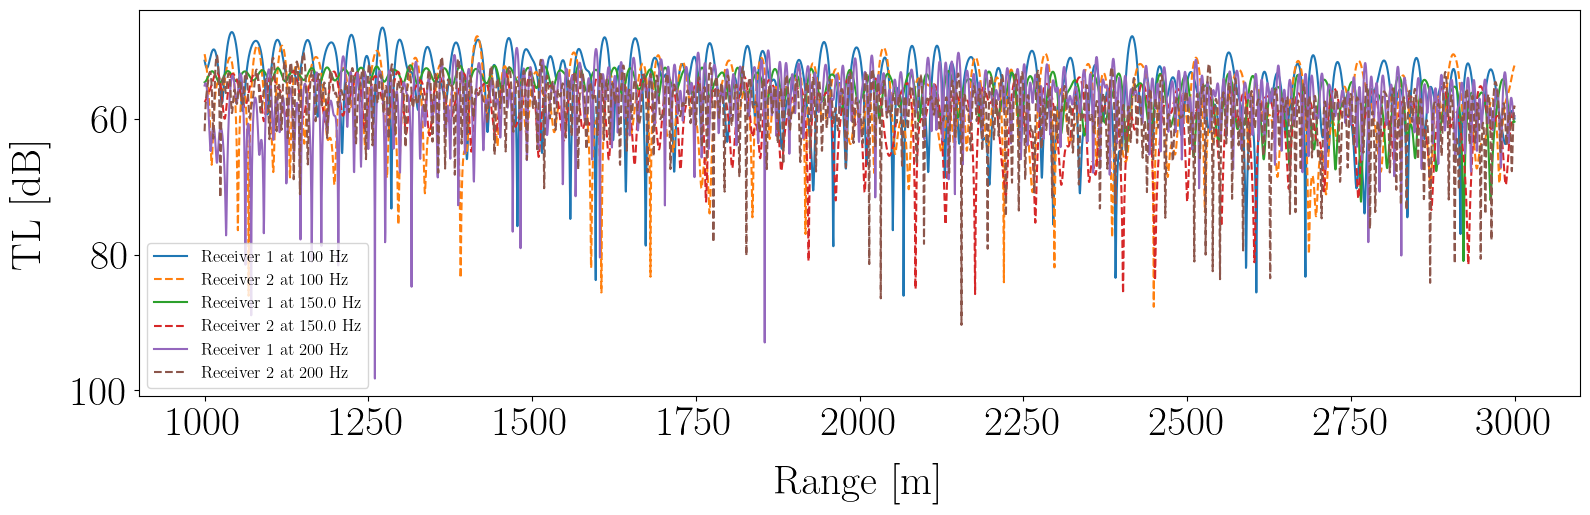

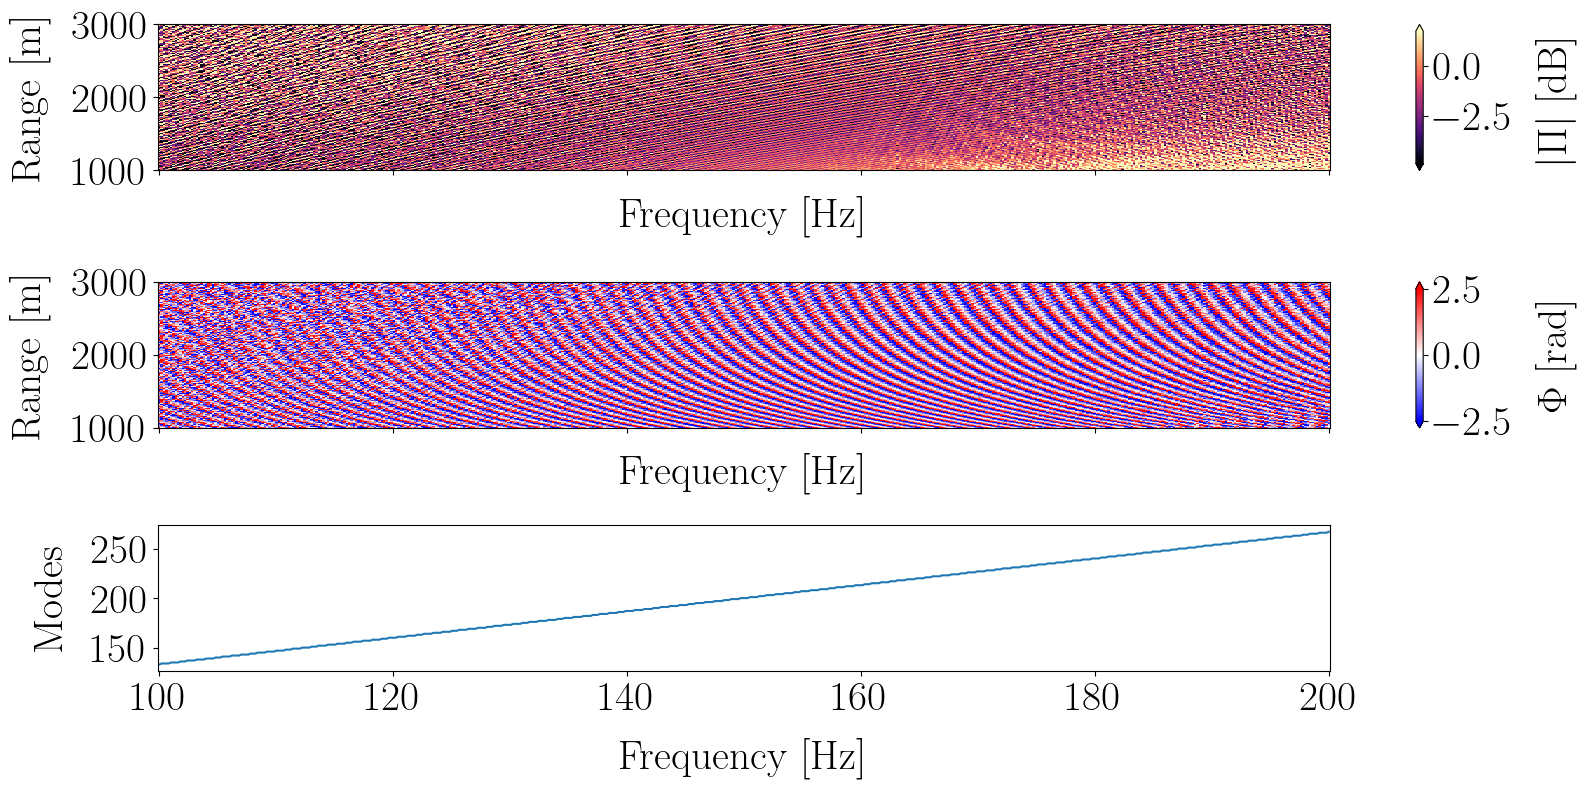

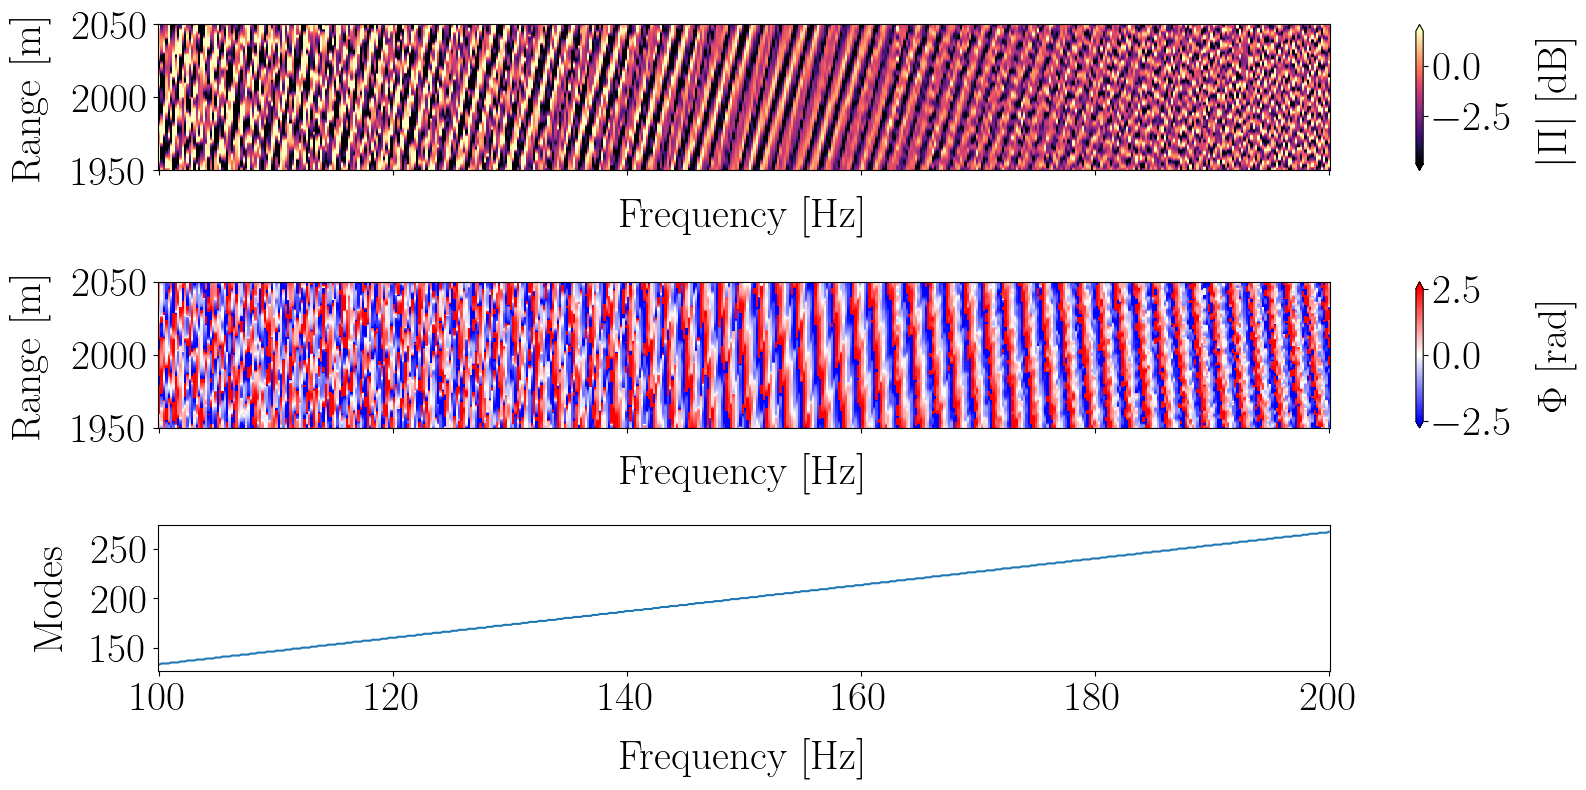

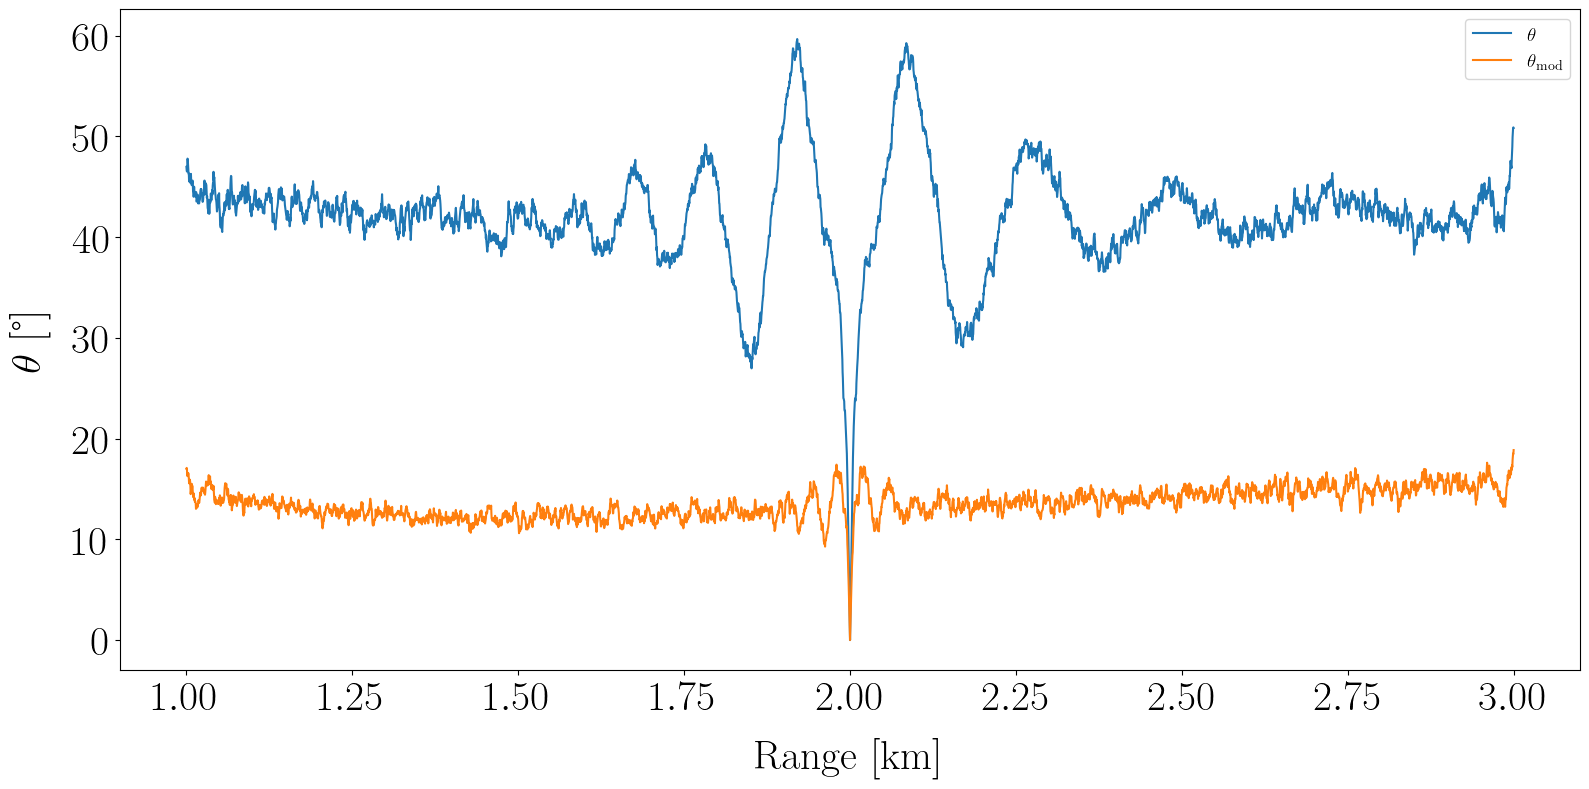

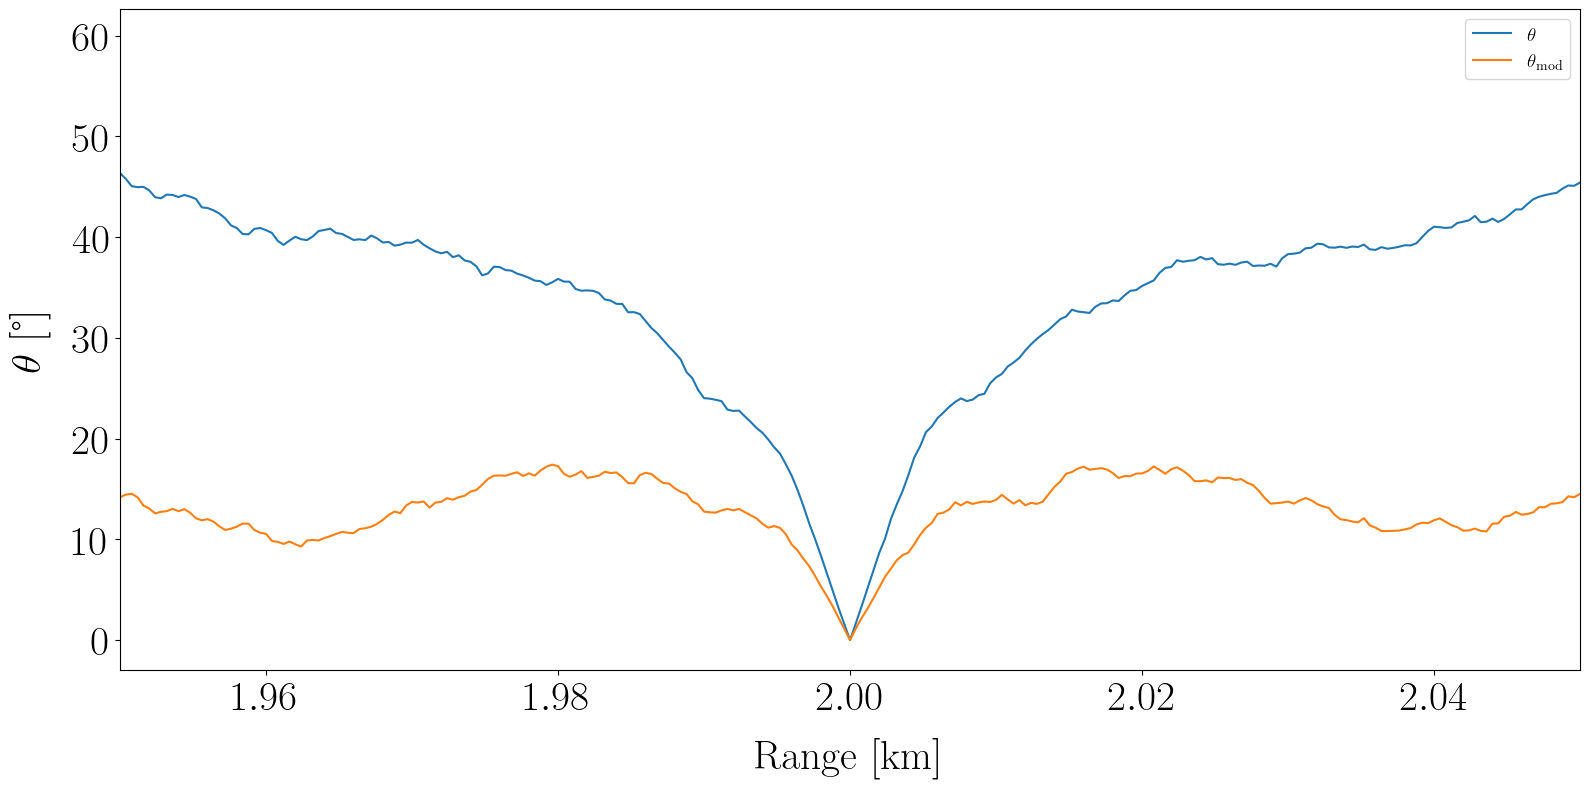

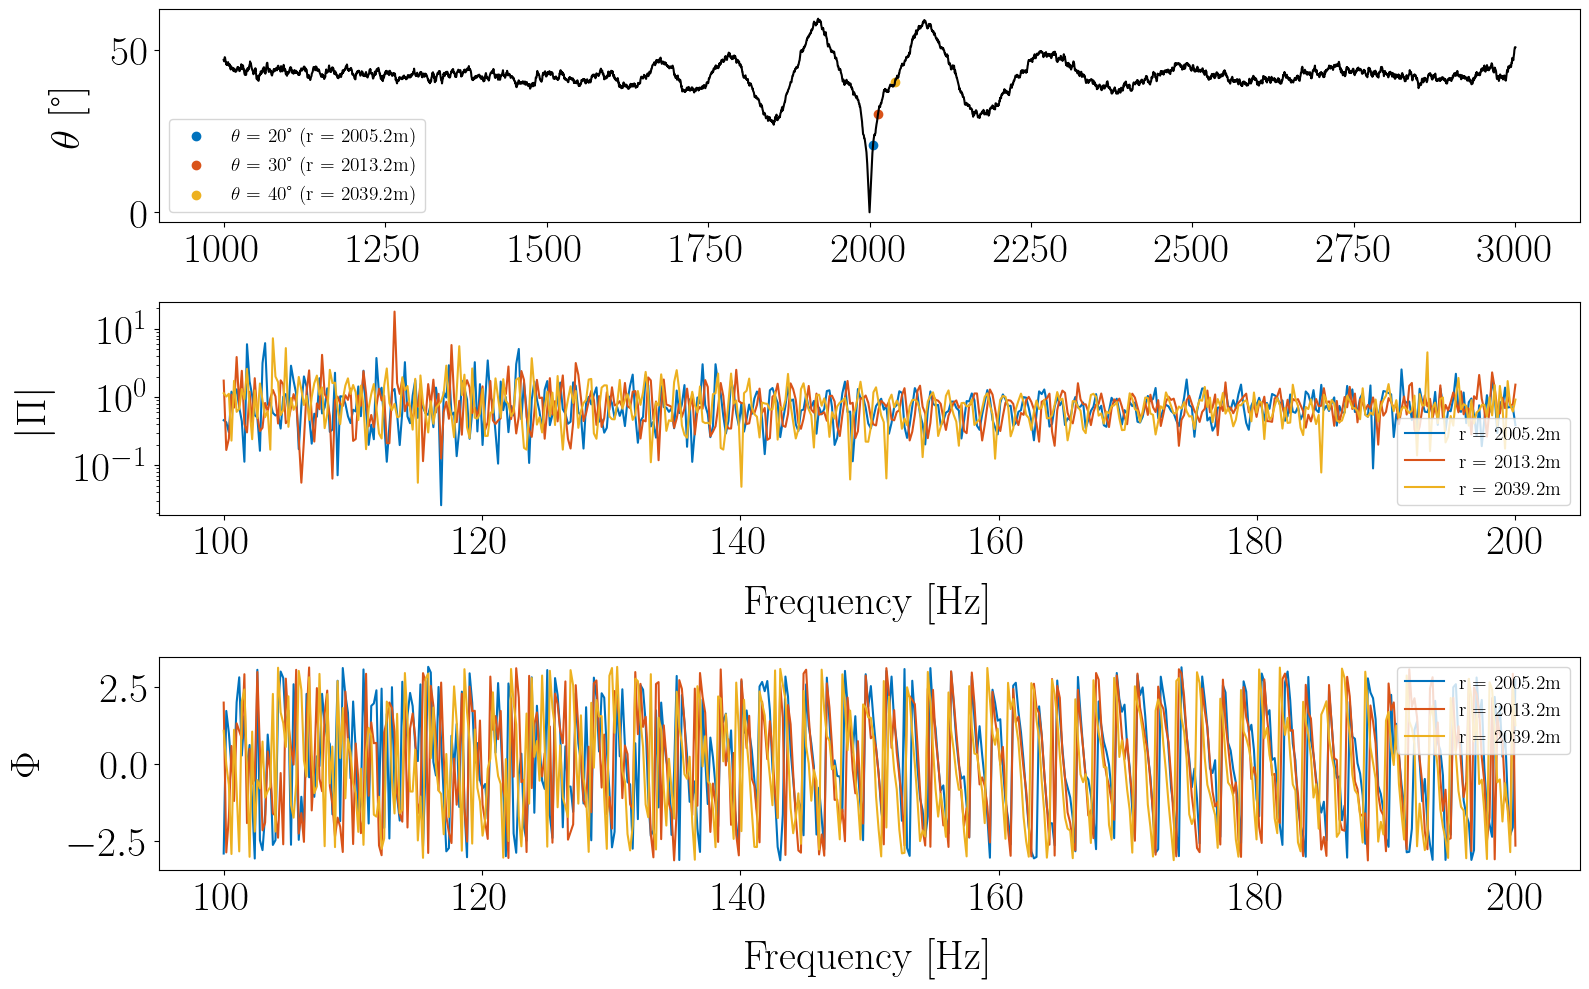

In [76]:
run_full_study(
    bottom_bc="perfectly_rigid",
    waveguide_depth=1000,
    d_inter_rcv=1000,
    z_rcv=999,
    src_ref_range=2 * 1e3,
    z_src=5,
    nrgrid=5001,
    delta_r=1 * 1e3,
    fmin=100,
    fmax=200,
    nfgrid=500,
)

Number of propagating modes at fmin = 100 Hz : 4
Number of propagating modes at fmax = 200 Hz : 8
Dataset computed


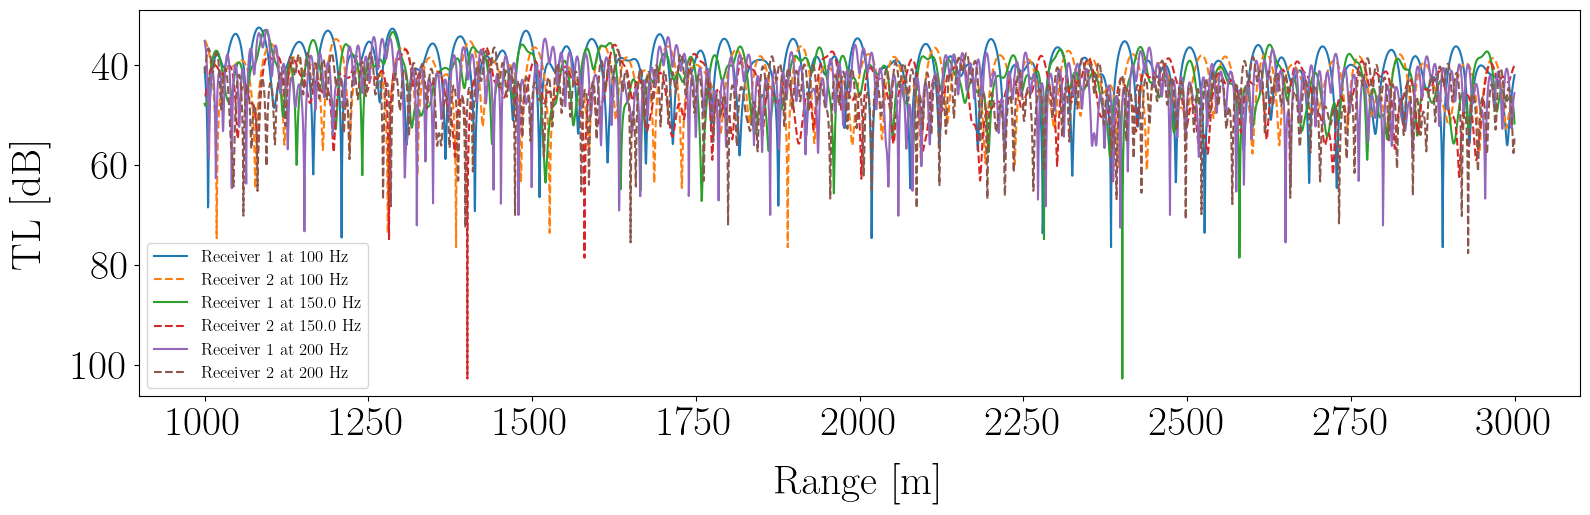

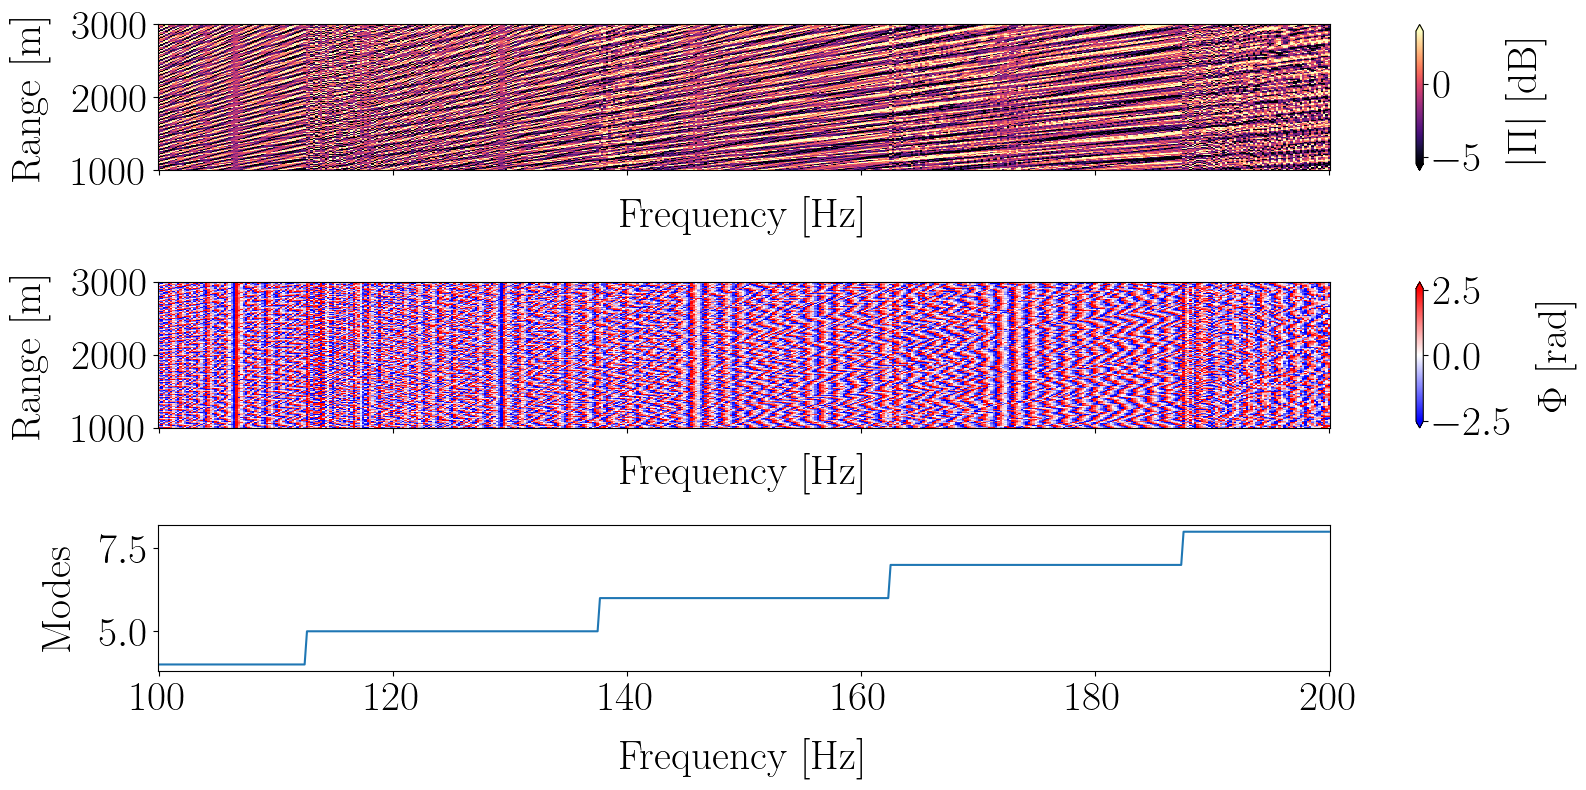

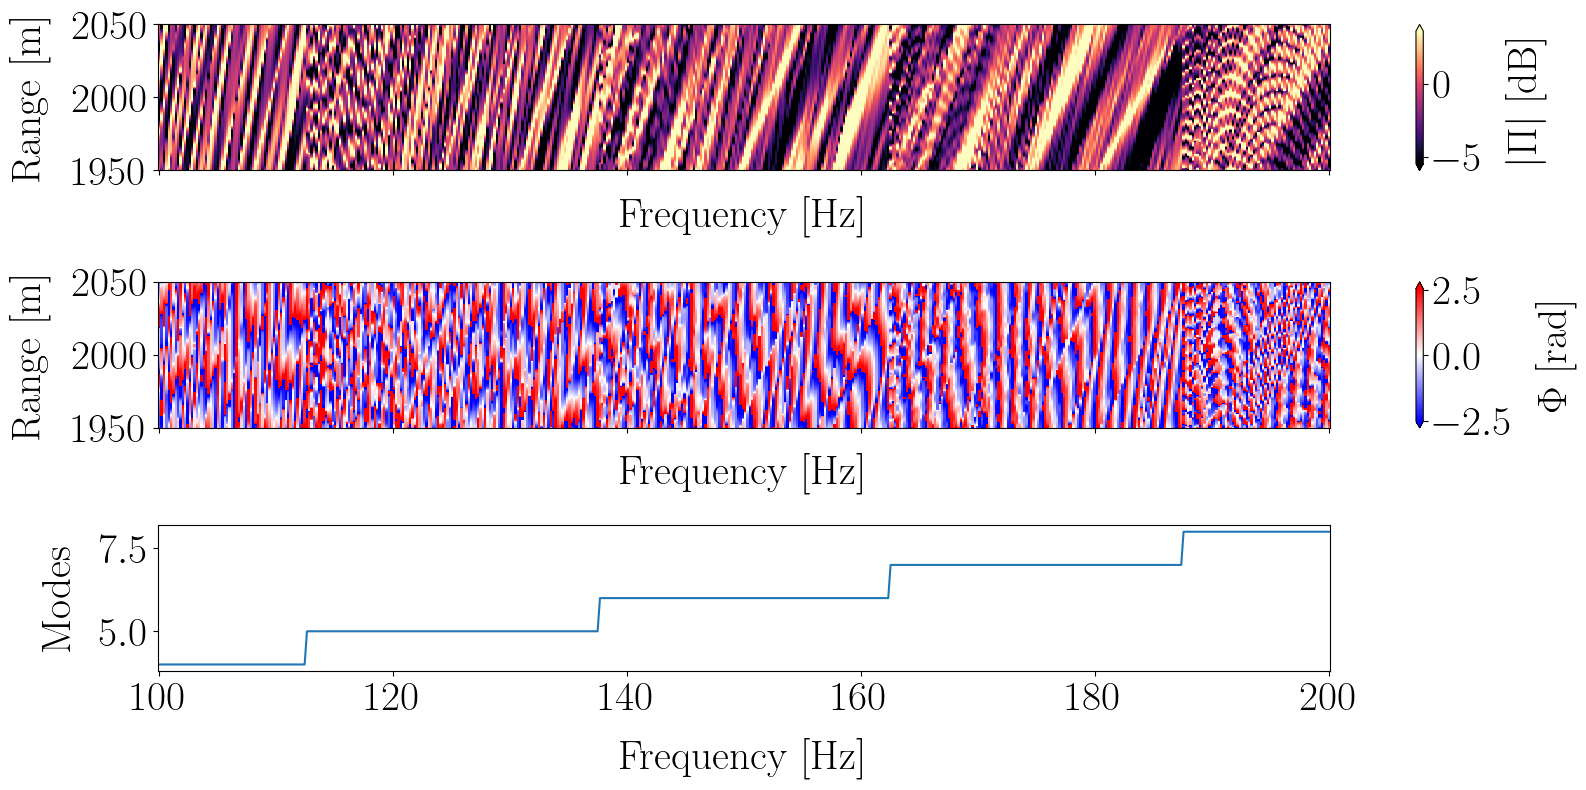

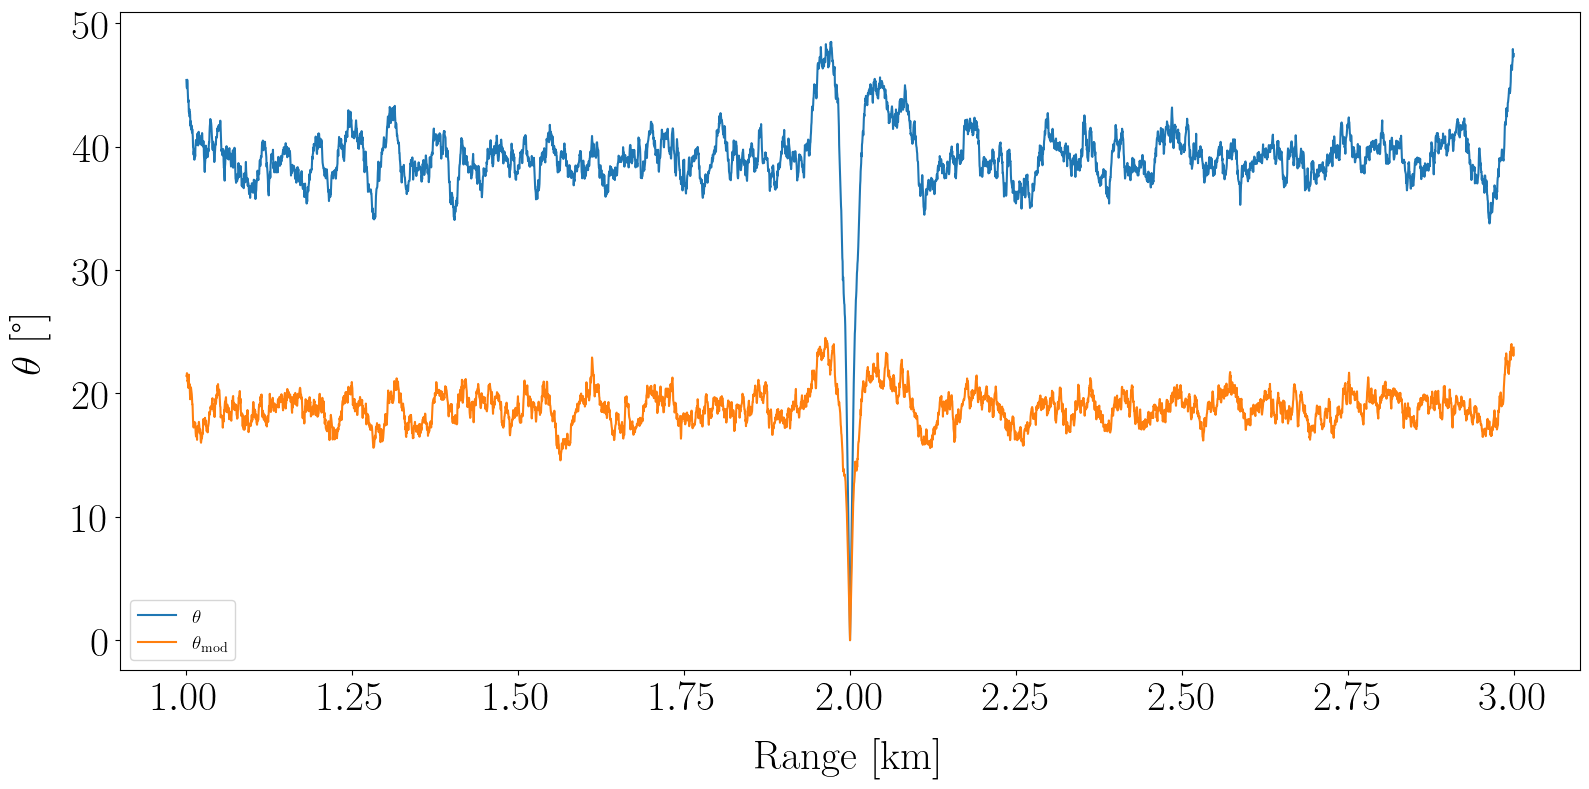

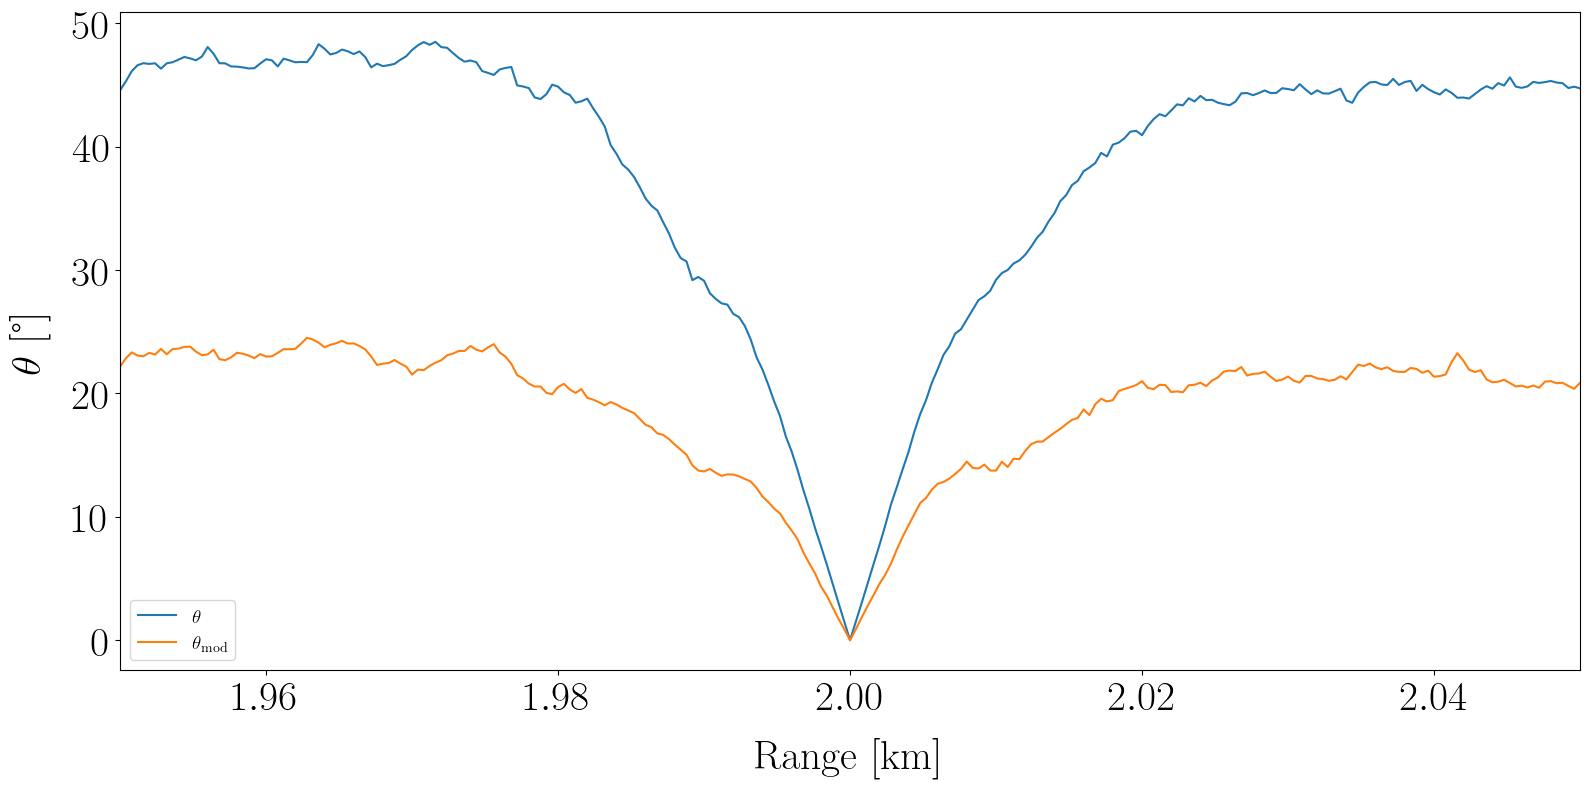

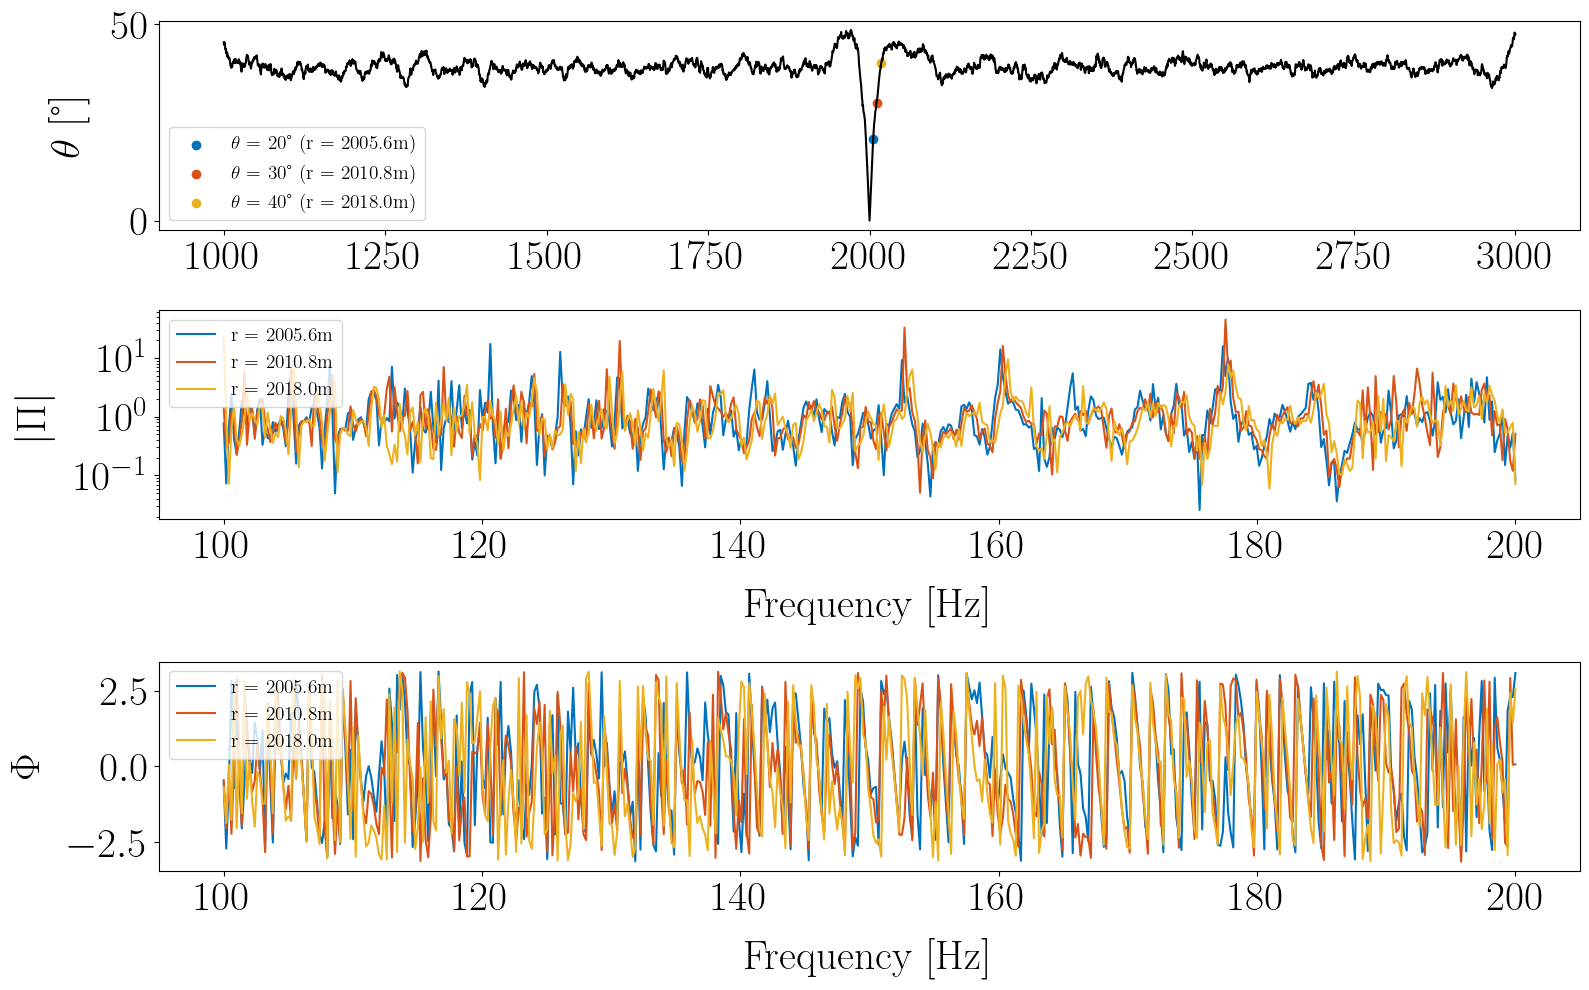

In [78]:
run_full_study(
    bottom_bc="perfectly_rigid",
    waveguide_depth=30,
    d_inter_rcv=1000,
    z_rcv=29,
    src_ref_range=2 * 1e3,
    z_src=5,
    nrgrid=5001,
    delta_r=1 * 1e3,
    fmin=100,
    fmax=200,
    nfgrid=500,
)

Number of propagating modes at fmin = 400 Hz : 16
Number of propagating modes at fmax = 800 Hz : 32
Dataset computed


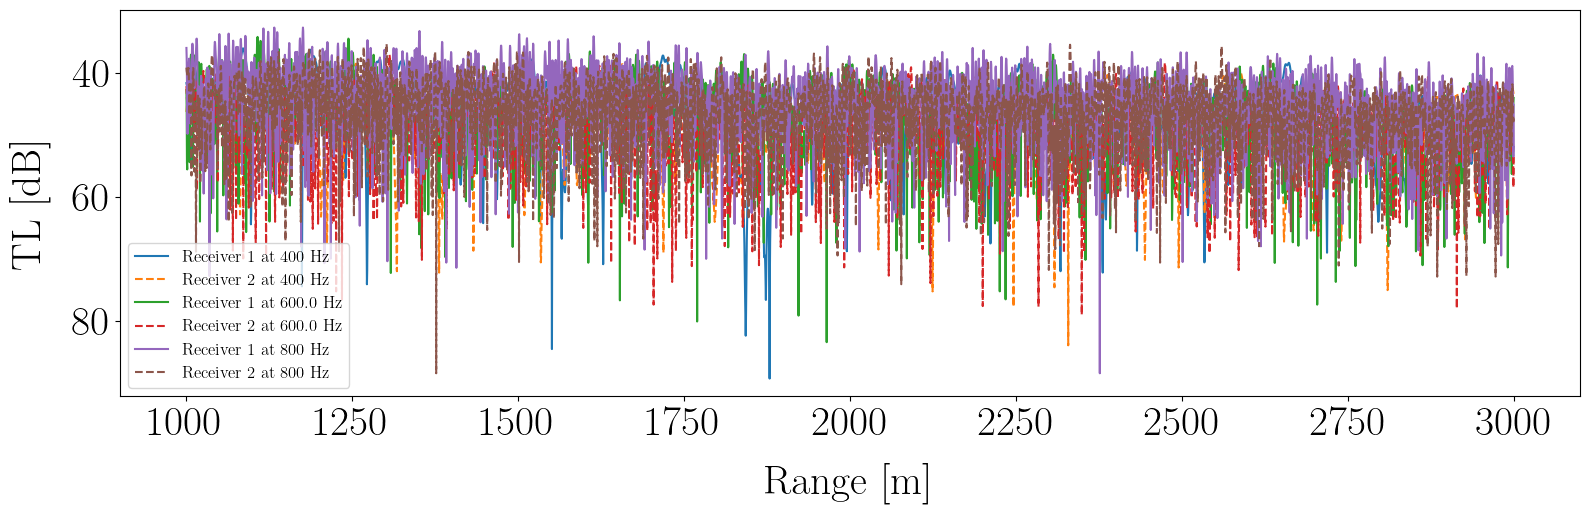

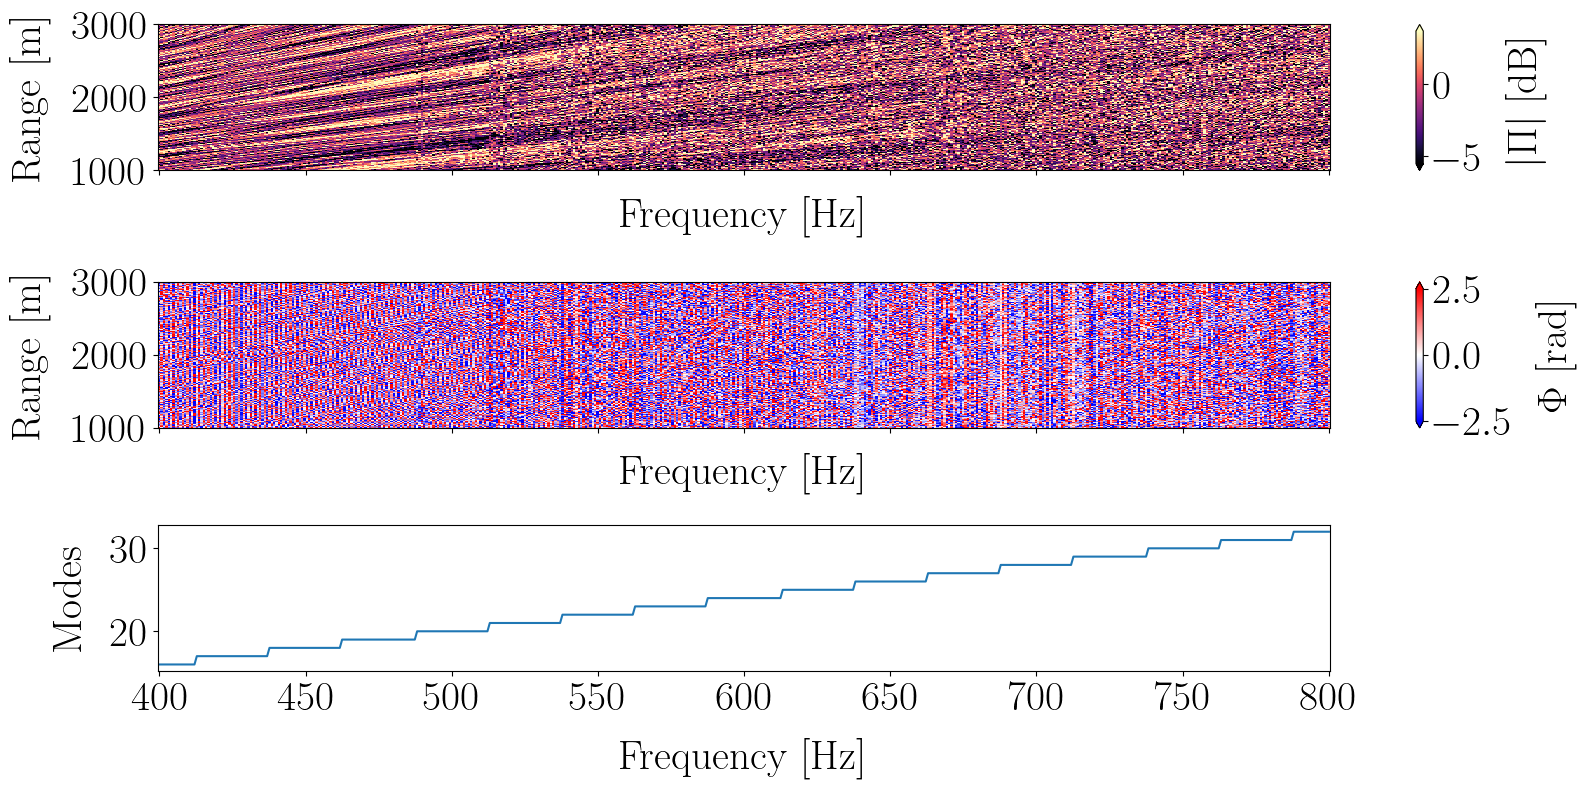

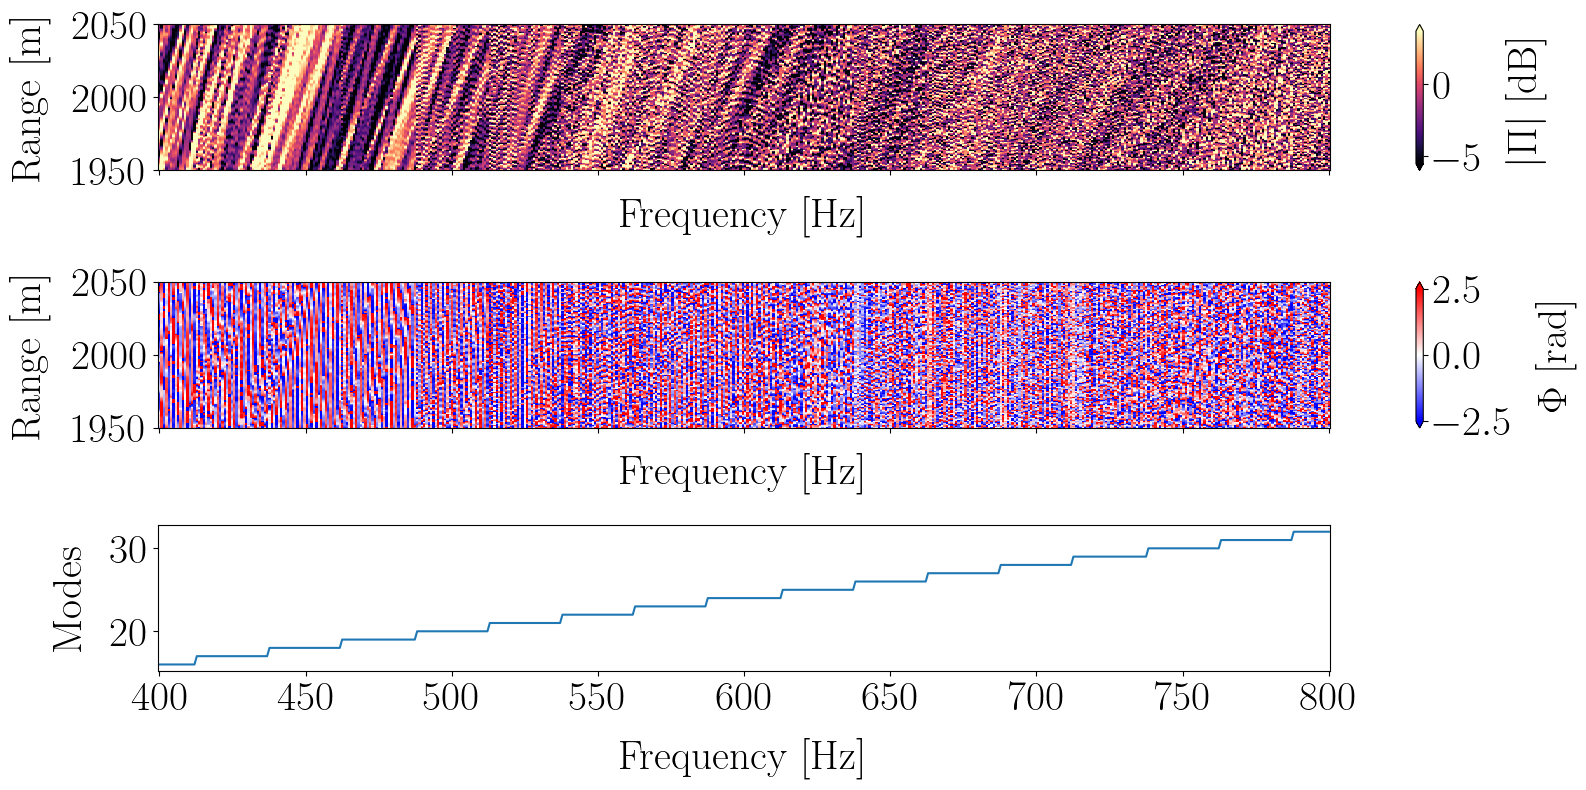

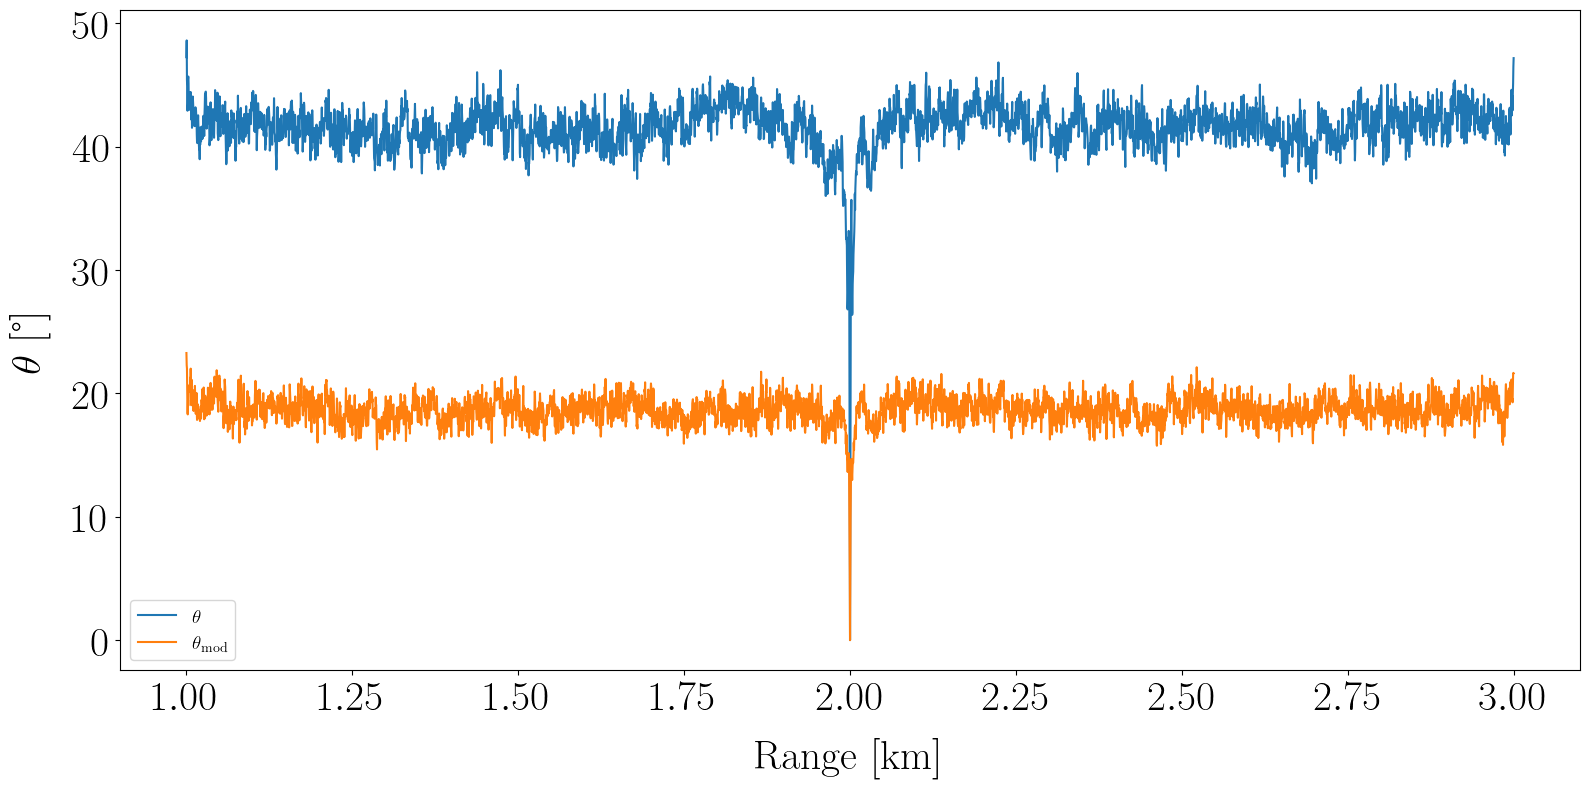

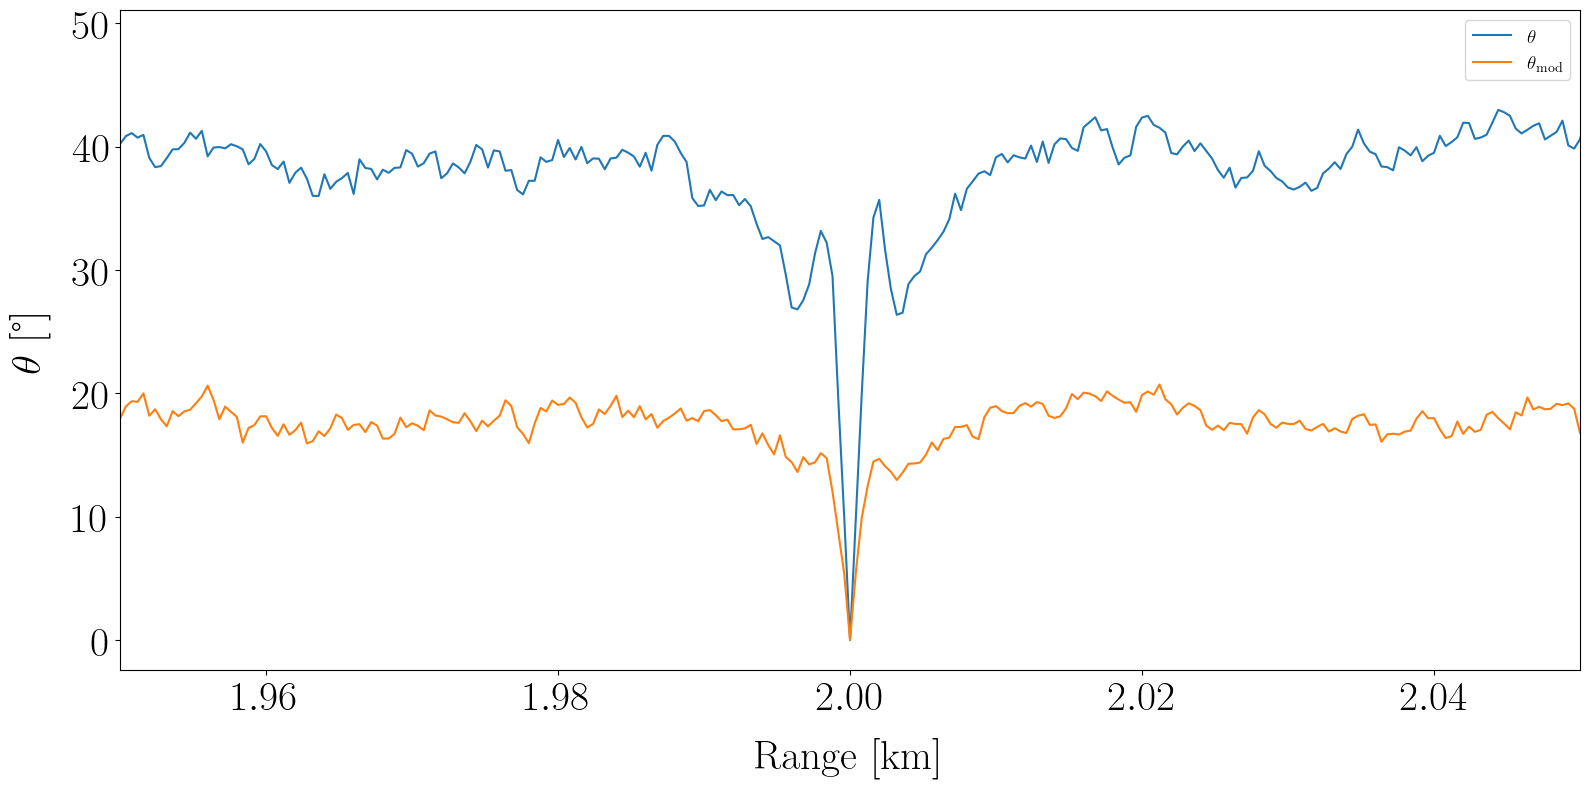

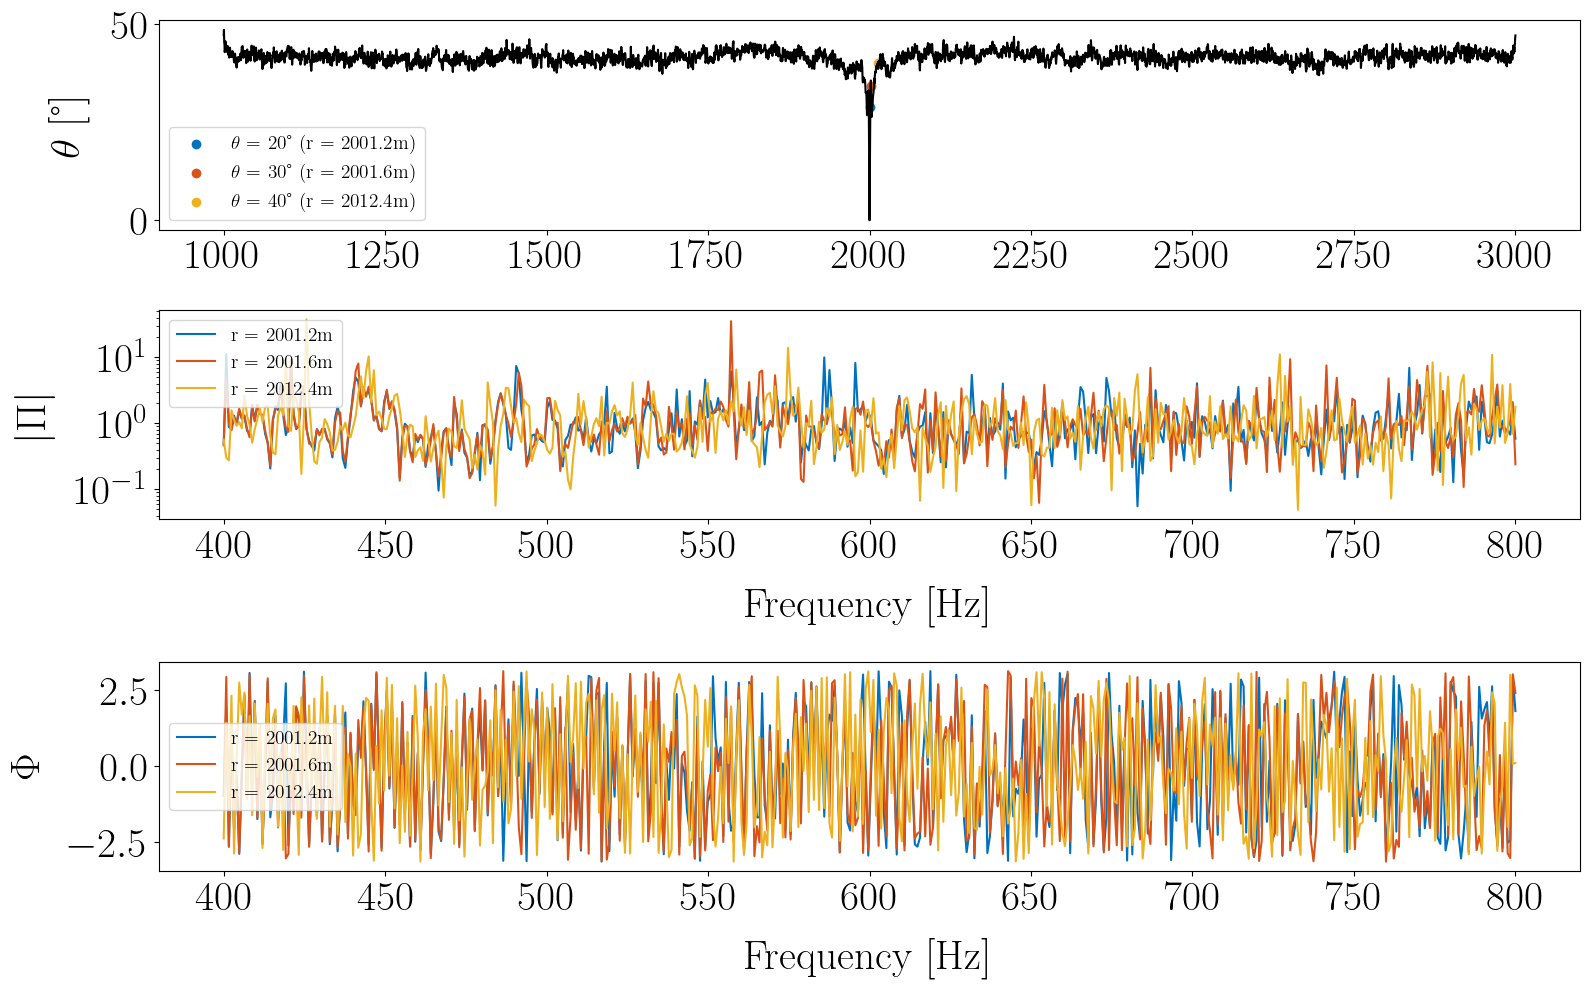

In [79]:
run_full_study(
    bottom_bc="perfectly_rigid",
    waveguide_depth=30,
    d_inter_rcv=1000,
    z_rcv=29,
    src_ref_range=2 * 1e3,
    z_src=5,
    nrgrid=5001,
    delta_r=1 * 1e3,
    fmin=400,
    fmax=800,
    nfgrid=500,
)

# Etape 1 : définition du guide d'onde et génération du jeu de données 

### Paramètres de la simulation

In [ ]:
# Waveguide
# bottom_bc = 'pressure_release' # Bottom boundary condition
bottom_bc = "perfectly_rigid"  # Bottom boundary condition
Dw = 1000 # Depth of the waveguide

# Receiver
d12 = 1000
z_a = 999 # Depth of receiver

# Source
r_ref = 2 * 1e3 # Reference range in meters
z_s = 5 # Depth of source 

# Define range vectors
nrgrid = 10001
delta_r = 1 * 1e3
rmin = r_ref - delta_r
rmax = r_ref + delta_r
r_grid = np.linspace(rmin, rmax, nrgrid)
r_grid_km = r_grid / 1e3
r_grid1 = r_grid    # Range from source to receiver 1
r_grid2 = r_grid + d12  # Range from source to receiver 2


In [ ]:
# Frequency vector
fmin = 10  # Minimum frequency in Hz
fmax = 20  # Maximum frequency in Hz
# fs = 100
# Ts = 1 / fs
# Tw = 5
# nw = Tw * fs
# Df = nw // 2
# print(Df)
Df = 500  # Number of frequency samples
f = np.linspace(fmin, fmax, Df) # Frequency vector

In [ ]:
abcd_labels = ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l"]

## Représentation de quelques fonctions de transfert 

In [ ]:
ff, rr, zz, p_field1 = field(
        f=f,
        z_src=z_a,    # Reciprocity: source is at antenna depth
        z=z_s,           # Reciprocity: receiver is at source depth
        r=r_grid1,
        depth=Dw,
        bottom_bc=bottom_bc,
    )
ff, _, _, p_field2 = field(
    f=f,
    z_src=z_a,    # Reciprocity: source is at antenna depth
    z=z_s,           # Reciprocity: receiver is at source depth
    r=r_grid2,                                    
    depth=Dw,
    bottom_bc=bottom_bc,
)
p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20

p_field1 = p_field1.squeeze()
p_field2 = p_field2.squeeze()

In [ ]:
n_propagating_modes_fmin = nb_propagating_modes(
    f=fmin, c=g.c0, depth=Dw, bottom_bc=bottom_bc
)
print(f"Number of propagating modes at fmin = {fmin} Hz : {n_propagating_modes_fmin}")
n_propagating_modes_fmax = nb_propagating_modes(
    f=fmax, c=g.c0, depth=Dw, bottom_bc=bottom_bc
)
print(f"Number of propagating modes at fmax = {fmax} Hz : {n_propagating_modes_fmax}")

In [ ]:
n_propa_modes_vs_f = np.array([nb_propagating_modes(f=fi, c=g.c0, depth=Dw, bottom_bc=bottom_bc)for fi in ff])


In [ ]:
# Derive first three modes
M = n_propagating_modes_fmax

modes = np.arange(1, M + 1).astype(int)
modal_fcts = []
z = np.linspace(0, Dw, int(1e4))  # Depths vector for modal functions
for m in modes:

    # psi_m = psi_normalised(m=m, z=z, depth=D, rho=g.rho_w, bottom_bc=bottom_bc)
    psi_m = psi(m=m, z=z, depth=Dw, bottom_bc=bottom_bc)

    # Cast to complex to match with the general form of the modal function
    psi_m = psi_m.astype(complex)
    modal_fcts.append(psi_m)

modal_fcts = np.array(modal_fcts)

# Plot modal functions
lfig = LargeFigure()

# fig, axs = plt.subplots(1, len(modes), sharey=True)
# # Revert y-axis
# axs[0].invert_yaxis()

# max_amp = np.max(np.abs(modal_fcts))
# axs[0].set_ylabel("Depth [m]")

# for i, m in enumerate(modes):
#     axs[i].plot(np.real(modal_fcts[i]), z, label=f"Real", linestyle="-", color="k")
#     axs[i].plot(np.imag(modal_fcts[i]), z, label=f"Im", linestyle="--", color="r")
#     axs[i].set_xlabel(m)
#     axs[i].set_xlim([-1.1 * max_amp, 1.1 * max_amp])
#     axs[i].grid()

#     # Add lines at source and receiver depths
#     axs[i].axhline(z_s, color="blue", linestyle="-", label="Source depth" if i == 0 else "")
#     axs[i].axhline(z_a, color="green", linestyle="-", label="Receiver depth" if i == 0 else "")

# plt.legend()

In [ ]:
# Plot TL at fmin, fmax and center frequency
lfig = LargeFigure(legend_fontsize=12)
frequencies_to_plot = [fmin, (fmin + fmax) / 2, fmax]
for freq in frequencies_to_plot:
    idx_freq = np.argmin(np.abs(ff - freq))

    tl1 = -20 * np.log10(4 * np.pi * np.abs(p_field1[idx_freq, :]) + 1e-20)
    tl2 = -20 * np.log10(4 * np.pi * np.abs(p_field2[idx_freq, :]) + 1e-20)

    plt.plot(r_grid / 1e3, tl1, label=f"Receiver 1 at {freq} Hz", linestyle="-")
    plt.plot(r_grid / 1e3, tl2, label=f"Receiver 2 at {freq} Hz", linestyle="--")
plt.legend()
plt.gca().invert_yaxis()

In [ ]:
# Compute RTF on the whole grid for a different number of modes
ff, rr, zz, pi_12 = calc_pi_12(
    f=f,
    r_grid1=r_grid1,
    r_grid2=r_grid2,
    z_source=z_s,
    z_antenna=z_a,
    depth=Dw,
    bottom_bc=bottom_bc,
)
# Shape pi_12 = (nf, 1, nr)

# Compute RTF at reference range
ff, rr_ref, zz, pi_12_ref = calc_pi_12(
    f=f,
    r_grid1=np.array([r_ref]),
    r_grid2=np.array([r_ref + d12]),
    z_source=z_s,
    z_antenna=z_a,
    depth=Dw,
    bottom_bc=bottom_bc,
)
# Shape pi_12_ref = (nf, 1, 1)

print("Dataset computed")

In [ ]:
# Add one dimension to fit the usual shape of RTF vectors (array of one for H_ref/H_ref)
# Target shape is (n_rcv, nf, nr)
pi_12 = pi_12.squeeze(axis=1) # (nf, nr)
pi_11 = np.ones_like(pi_12).astype(np.complex64)
pi_12_full = np.array([pi_11, pi_12])       # (nrcv, nf, nr)

# Same thing for pi_ref -> (nrcv, nf)
pi_12_ref = pi_12_ref.squeeze(axis=(1, 2))
pi_11_ref = np.ones_like(pi_12_ref).astype(np.complex64)
pi_12_ref_full = np.array([pi_11_ref, pi_12_ref])

In [ ]:
ds = xr.Dataset(
    data_vars=dict(
        data=(["h_index", "f", "r"], pi_12_full),
        phase=(["h_index", "f", "r"], np.angle(pi_12_full)),
        module=(["h_index", "f", "r"], np.abs(pi_12_full)),
        data_ref=(["h_index", "f"], pi_12_ref_full),
        nb_modes=(["f"], n_propa_modes_vs_f)
    ),
    coords=dict(
        f=ff,
        r=rr.squeeze(),
        h_index=[1, 2],
    ),
    attrs=dict(
        description=f"RTF dataset for an ideal waveguide. The antenna is composed of two receivers separated by d12={d12}m. The source is at z_s={z_s}m and the antenna at z_a={z_a}m in a waveguide of depth Dw={Dw}m.",
        bottom_bc=bottom_bc,
        Dw=Dw,
        z_s=z_s,
        z_a=z_a,
        r_ref=r_ref,
        d12=d12,
        h_index_ref=1,
    ),
)

# Add usefull attrs 
ds.f.attrs = {
    "unit": "Hz",
    "long_name": "Frequency"
}
ds.r.attrs = {
    "unit": "m", 
    "long_name": "Range"
}

In [ ]:
print(ds)

In [ ]:
# Cuttof freq for mode 2
Mi = 5
omegac2 = (Mi - 1/2) * np.pi * g.c0 / Dw
print(f"Cutoff frequency for mode {Mi}: {omegac2/(2*np.pi)} Hz")

omegac2 = (M - 1 / 2) * np.pi * g.c0 / Dw
print(f"Cutoff frequency for mode {M}: {omegac2/(2*np.pi)} Hz")

In [ ]:
ds

## Variation du module et de la phase de la composante non unitaire du vecteur de RTF en fonction de la distance au capteur de référence 

In [ ]:
lfig = LargeFigure(legend_fontsize=14, size=(16, 8))
fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True)
ax1, ax2, ax3 = axs

rtf_mod = 10*np.log10(ds.module)


rtf_mod.sel(h_index=2).plot(x="f", cmap="magma", vmin=np.percentile(rtf_mod, 5), vmax=np.percentile(rtf_mod, 95), ax=ax1, cbar_kwargs={"label":r"$\lvert \Pi\rvert$ [dB]"})

rtf_phase = ds.phase
rtf_phase.sel(h_index=2).plot(
    x="f",
    cmap="bwr",
    vmin=np.percentile(rtf_phase, 5),
    vmax=np.percentile(rtf_phase, 95),
    ax=ax2,
    cbar_kwargs={"label": r"$\Phi$ [rad]"},
)

ds.nb_modes.plot(ax=ax3)
ax3.set_ylabel("Modes")

ax1.set_title("")
ax2.set_title("")
ax3.set_title("")

fpath = os.path.join(sensibility_img_folder, "rtf_module_phase_f_r_plan.png")
plt.savefig(fpath)
# plt.xscale("log")

Le module et la phase du rapport des fonctions de transfert présentent des structures similaires à celles observées sur les données Fiberscope Groix. En particulier, on peut observer des structures dans le plan (f, r). 
Les discontinuités observables sur le module et la phase traduisent le passage des fréquences de coupure des différents modes. Par exemple, la fréquence de coupure du mode 5 est de 112.5 Hz et on passe alors de 4 à 5 modes propagatifs. 

In [ ]:
lfig = LargeFigure(legend_fontsize=14, size=(16, 8))
fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True)
ax1, ax2, ax3 = axs

rtf_mod = 10 * np.log10(ds.module)


rtf_mod.sel(h_index=2).plot(
    x="f",
    cmap="magma",
    vmin=np.percentile(rtf_mod, 5),
    vmax=np.percentile(rtf_mod, 95),
    ax=ax1,
    cbar_kwargs={"label": r"$\lvert \Pi\rvert$ [dB]"},
)

rtf_phase = ds.phase
rtf_phase.sel(h_index=2).plot(
    x="f",
    cmap="bwr",
    vmin=np.percentile(rtf_phase, 5),
    vmax=np.percentile(rtf_phase, 95),
    ax=ax2,
    cbar_kwargs={"label": r"$\Phi$ [rad]"},
)

ds.nb_modes.plot(ax=ax3)
ax3.set_ylabel("Modes")

ax1.set_title("")
ax2.set_title("")
ax3.set_title("")

ax1.set_ylim([1975, 2025])
ax2.set_ylim([1975, 2025])

fpath = os.path.join(sensibility_img_folder, "rtf_module_phase_f_r_plan_zoom.png")
plt.savefig(fpath)
# plt.xscale("log")

In [ ]:
plt.figure()
np.abs(ds.data).sel(h_index=2).isel(f=[0, 100, 200]).plot(hue="f")
plt.yscale("log")

In [ ]:
plt.figure()
ds.module.sel(h_index=2).sel(r=[1975, 2000, 2025], method="nearest").plot(hue="r")
plt.yscale("log")

In [ ]:
df = ds.f.values[1] - ds.f.values[0]
plt.figure()
ds.module.sel(h_index=2).sel(r=[2000], method="nearest").plot(color="k", label="r = 2000 m")

# r = 1975 m
mod = ds.module.sel(h_index=2).sel(r=[1975], method="nearest")
nshift_f = 20
shift_f = df * nshift_f
mod_roll = mod.roll(f=nshift_f)
mod_roll.plot(color=color(0), label=f"r = 1975 m, shift = {shift_f:.2f} Hz")

# r = 2025
mod = ds.module.sel(h_index=2).sel(r=[2025], method="nearest")
nshift_f = -20
shift_f = df * nshift_f
mod_roll = mod.roll(f=nshift_f)
mod_roll.plot(color=color(1), label=f"r = 2025 m, shift = {shift_f:.2f} Hz")
plt.yscale("log")
plt.legend()

In [ ]:
rtf_ref = ds.data.sel(r=[2000], method="nearest")
rtf_ref = rtf_ref.values.squeeze(axis=-1)

rtf_r1 = ds.data.sel(r=[1975], method="nearest")
nshift_f = 20
shift_f = df * nshift_f
rtf_r1_shift = rtf_r1.roll(f=nshift_f)
rtf_r1 = rtf_r1.values.squeeze(axis=-1)
rtf_r1_shift = rtf_r1_shift.values.squeeze(axis=-1)

rtf_r2 = ds.data.sel(r=[2025], method="nearest")
nshift_f = -20
shift_f = df * nshift_f
rtf_r2_shift = rtf_r2.roll(f=nshift_f)  
rtf_r2 = rtf_r2.values.squeeze(axis=-1)
rtf_r2_shift = rtf_r2_shift.values.squeeze(axis=-1)

# Compute dist
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
# theta_r1 = D_hermitian_angle_fast(
#     rtf_ref=rtf_ref,
#     rtf=rtf_r1,
#     **dist_kwargs,
# )
# theta_r1_shift = D_hermitian_angle_fast(
#     rtf_ref=rtf_ref,
#     rtf=rtf_r1_shift,
#     **dist_kwargs,
# )
# theta_r2 = D_hermitian_angle_fast(
#     rtf_ref=rtf_ref,
#     rtf=rtf_r2,
#     **dist_kwargs,
# )
# theta_r2_shift = D_hermitian_angle_fast(
#     rtf_ref=rtf_ref,
#     rtf=rtf_r2_shift,
#     **dist_kwargs,
# )

theta_r1 = D_hermitian_angle_fast(
    rtf_ref=np.abs(rtf_ref),
    rtf=np.abs(rtf_r1),
    **dist_kwargs,
)
theta_r1_shift = D_hermitian_angle_fast(
    rtf_ref=np.abs(rtf_ref),
    rtf=np.abs(rtf_r1_shift),
    **dist_kwargs,
)
theta_r2 = D_hermitian_angle_fast(
    rtf_ref=np.abs(rtf_ref),
    rtf=np.abs(rtf_r2),
    **dist_kwargs,
)
theta_r2_shift = D_hermitian_angle_fast(
    rtf_ref=np.abs(rtf_ref),
    rtf=np.abs(rtf_r2_shift),
    **dist_kwargs,
)

In [ ]:
print(f"r1 : theta no shift {theta_r1}°, theta shift {theta_r1_shift}°")
print(f"r2 : theta no shift {theta_r2}°, theta shift {theta_r2_shift}°")

In [ ]:
plt.figure()

for fi in [120, 140, 160]:
    rtf_mod = 10 * np.log10(np.abs(ds.data)).sel(f=fi, method="nearest").sel(h_index=2)

    autocorr = np.correlate(rtf_mod, rtf_mod, mode="same")
    autocorr /= np.max(autocorr)
    step_r = rtf_mod.r.values[1] - rtf_mod.r.values[0]
    lags_r = sp.correlation_lags(rtf_mod.size, rtf_mod.size, mode="same") * step_r

    # Distance d'autocorrélation
    pos_shift = lags_r >= 0
    autocorr_pos_shift = autocorr[pos_shift]
    d_half_autocorr_idx = np.where(autocorr_pos_shift - 1/2 >= 0)[0][-1]
    d_autocorr = d_half_autocorr_idx * 2 * step_r

    lw = 1500 / fi 
    plt.plot(
        lags_r,
        autocorr,
        label=f"f = {fi:.1f} Hz, l = {lw:.1f}m, d_corr = {d_autocorr}m, l/d_corr = {lw/d_autocorr:.1f}",
    )

plt.xlabel("Range shift [m]")
plt.ylabel("RTF module autocorr")
plt.legend()

In [ ]:
plt.figure()

for fi in [100, 150, 200]:
    rtf = ds.data.sel(f=fi, method="nearest").sel(h_index=2)

    autocorr = np.correlate(rtf, rtf, mode="same")
    autocorr = np.abs(autocorr)
    autocorr /= np.max(autocorr)
    step_r = rtf.r.values[1] - rtf.r.values[0]
    lags_r = sp.correlation_lags(rtf.size, rtf.size, mode="same") * step_r

    # Distance d'autocorrélation
    pos_shift = lags_r >= 0
    autocorr_pos_shift = autocorr[pos_shift]
    d_half_autocorr_idx = np.where(autocorr_pos_shift - 1 / 2 >= 0)[0][-1]
    d_autocorr = d_half_autocorr_idx * 2 * step_r

    lw = 1500 / fi
    plt.plot(
        lags_r,
        autocorr,
        label=f"f = {rtf.f.values:.1f} Hz, l = {lw:.1f}m, d_corr = {d_autocorr}m, l/d_corr = {lw/d_autocorr:.1f}",
    )

plt.xlabel("Range shift [m]")
plt.ylabel("Complex RTF autocorr")
plt.legend()

# plt.xlim([-30, 30])

In [ ]:

plt.figure()
shift_f_domain = mult_along_axis(
    ds.data.sel(h_index=2).values, np.exp(-1j * 2 * np.pi * 10 * ds.f.values), axis=0
)
rtf_time_domain = np.fft.irfft(shift_f_domain, n=4*ds.f.size, axis=0)
plt.pcolormesh(
    rtf_time_domain.T,
    cmap="jet",
    vmin=np.percentile(rtf_time_domain, 1),
    vmax=np.percentile(rtf_time_domain, 99),
)
plt.colorbar()
# rtf_mod = 10 * np.log10(np.abs(ds.data))
# rtf_mod.plot(
#     x="f", cmap="magma", vmin=np.percentile(rtf_mod, 5), vmax=np.percentile(rtf_mod, 95)
# )
# plt.xscale("log")
print(rtf_time_domain.shape)
plt.xlim([0, 1000])

In [ ]:
# plt.figure()
# # rtf_time_domain = np.fft.irfft(ds.data.isel(r=100))

# # plt.plot(rtf_time_domain)
# plt.plot(rtf_time_domain[:, 1])
# plt.plot(rtf_time_domain[:, 25])
# plt.plot(rtf_time_domain[:, 50])

# # plt.plot(rtf_time_domain[2,:])
# # plt.xlim([0, 1000])

In [ ]:
rtf_phase = np.angle(ds.data.sel(h_index=2))
print(rtf_phase.shape)
print(rtf_mod.r.shape)

In [ ]:
plt.figure()
# rtf_phase = np.angle(ds.data)
plt.pcolormesh(
    # rtf_mod.r.values, 
    # rtf_mod.f.values,
    rtf_phase.T,
    cmap="jet",
    # vmin=np.percentile(rtf_phase, 5),
    # vmax=np.percentile(rtf_phase, 95),
)
# rtf_mod.plot(
#     x="f", cmap="magma", vmin=np.percentile(rtf_mod, 5), vmax=np.percentile(rtf_mod, 95)
# )
# plt.xscale("log")

# Dynamic Time Warping 

In [ ]:
# # Dynamic Time Warping
# from dtaidistance import dtw

# dist = []
# for ir, r in enumerate(ds.r.values):
#     d_dtw = dtw.distance(
#         np.abs(ds.data.sel(r=r)),
#         np.abs(ds.data_ref),
#     )
#     # d_dtw = dtw.distance(
#     #     rtf_time_domain[:, ir],
#     #     rtf_time_domain[:, ds.r.size//2],
#     # )

#     dist.append(d_dtw)
#     print(r, d_dtw)

# print(dist)

In [ ]:
# plt.figure()
# plt.plot(r_grid_km, dist / np.max(dist))
# plt.xlabel("Range [km]")
# plt.ylabel("Distance")

### Distance Euclidienne 

In [ ]:
# d_Euc = np.linalg.norm((ds.data - ds.data_ref.values[:, np.newaxis]), axis=0)
d_Euc = np.linalg.norm((ds.data - ds.data_ref.values[..., np.newaxis]), axis=0)
d_Euc = np.mean(d_Euc, axis=0)  # Take mean along f axis 

In [ ]:
plt.figure()
plt.plot(r_grid_km, d_Euc / np.max(d_Euc))
plt.xlabel("Range [km]")
plt.ylabel("Distance")

plt.figure()
plt.plot(r_grid_km, d_Euc / np.max(d_Euc))
plt.xlabel("Range [km]")
plt.ylabel("Distance")
plt.xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)

### Angle hermitien

In [ ]:
rtf = ds.data.values[..., np.newaxis]

# Compute dist
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
# theta = D_hermitian_angle_fast(
#     rtf_ref=ds.data_ref.values,
#     rtf=rtf,
#     **dist_kwargs,
# )

# theta = D_hermitian_angle_fast(
#     rtf_ref=np.abs(ds.data_ref.values),
#     rtf=np.abs(rtf),
#     **dist_kwargs,
# )

theta = D_hermitian_angle_fast(
    rtf_ref=np.angle(ds.data_ref.values),
    rtf=np.angle(rtf),
    **dist_kwargs,
)

In [ ]:
theta.shape

In [ ]:
plt.figure()
plt.plot(r_grid_km, theta)
plt.xlabel("Range [km]")
plt.ylabel(r"$\theta$ [°]")

plt.figure()
plt.plot(r_grid_km, theta)
plt.xlabel("Range [km]")
plt.ylabel(r"$\theta$ [°]")
plt.xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)

In [ ]:
lfig = LargeFigure(legend_fontsize=14)
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)
ax1, ax2 = axs


ax1.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax1.plot(
    r_grid_km,
    d_hermitien / np.max(d_hermitien),
    color=color(1),
    label="Hermitian angle",
)

ax1.legend(loc="lower right")


ax2.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax2.plot(
    r_grid_km,
    d_hermitien / np.max(d_hermitien),
    color=color(1),
    label="Hermitian angle",
)

ax2.set_xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
ax2.legend(loc="lower right")

fig.supxlabel("Range [km]")
fig.supylabel("Normalized distance")

# Add (a), (b) annatotation for subfigures
for i, ax in enumerate(axs):
    ax.text(
        0.95,
        0.98,
        f"({abcd_labels[i]})",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
    )

# Save figure
fname = f"dist_euclidean_hermitian_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

In [ ]:
lfig = LargeFigure(legend_fontsize=14)
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)
ax1, ax2 = axs


ax1.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax1.plot(r_grid_km, d_hermitien / np.max(d_hermitien),  color=color(1), label="Hermitian angle")

ax1.legend(loc="lower right")


ax2.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax2.plot(
    r_grid_km,
    d_hermitien / np.max(d_hermitien),
    color=color(1),
    label="Hermitian angle",
)

ax2.set_xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
ax2.legend(loc="lower right")

fig.supxlabel("Range [km]")
fig.supylabel("Normalized distance")

# Add (a), (b) annatotation for subfigures
for i, ax in enumerate(axs):
    ax.text(
        0.95,
        0.98,
        f"({abcd_labels[i]})",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
    )

# Save figure
fname = f"dist_euclidean_hermitian_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

### Commentaires distance euclidienne et hermitienne

Les distances euclidienne et hermitienne présentent des résultats analogues. 

Proche du point de référence la distance est monotone, traduisant ainsi la structure localement euclidienne de l'espace des données. En revanche, lorsque l'on s'éloigne de quelques centaines de mètres du point de référence, la distance  n'est plus monotone et oscille autour d'un palier. 

Ces deux distances ne sont donc pas appropriée pour mesurer la proximité (en range seulement ici) de la source au point de référence. 

### Distance PCA

Les données sont linéairement projetées sur les composantes principales du jeu de données. La projection étant linéaire, la variété est donc supposée "linéaire / plate".  

La librairie sklearn ne propose pas d'implémentation de la PCA pour des données complexes. Pour palier ce problème on implémente la PCA à la main avec l'algo de SVD. 


* Remarque : 

On peut vérifier que notre algorithme converge vers la même solution que l'implémentation sklearn. Dans le cas du jeu de données étudié ici il faut toutefois forcer le mode de calcul de sklearn (svd_solver="full") afin d'éviter que l'algorithme ne bascule automatiquement sur l'algorithme randomized SVD (Halko et al.). 

In [ ]:
def pca_svd(X, k):
    # 1. Centrage
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    # 2. SVD
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    # 3. Directions principales
    W = Vt[:k].T

    # 4. Projection
    X_pca = X_centered @ W

    return X_pca, W, S, mean

#### Rapide de test pour vérifier que les deux solutions sont identiques 

In [ ]:
# d = 1
# X = ds.data.real.T.values
# X = X[:300, :1000]  # Reduce size for faster computation
# X_pca_manual, W_manual, S_manual, mean_manual = pca_svd(X, k=d)

# from sklearn.decomposition import PCA

# pca = PCA(n_components=d, svd_solver="full")
# X_pca_sklearn = pca.fit_transform(X)

In [ ]:
# print("Axes PCA (manuel) :\n", W_manual)
# print("Axes PCA (sklearn) :\n", pca.components_.T)
# print("Projection manuelle :\n", X_pca_manual)
# print("Projection sklearn :\n", X_pca_sklearn)
# np.allclose(X_pca_manual, X_pca_sklearn)
# np.allclose(X_pca_manual, -X_pca_sklearn)

# n = X.shape[0]
# explained_variance_manual = (S_manual**2) / (n - 1)
# ratio_manual = explained_variance_manual / np.sum(explained_variance_manual)

# print("Variance expliquée sklearn :", pca.explained_variance_)
# print("Variance expliquée manuelle :", explained_variance_manual[:d])
# print("Ratio variance expliquée sklearn :", pca.explained_variance_ratio_)
# print("Ratio variance expliquée manuelle :", ratio_manual[:d])
# np.allclose(explained_variance_manual[:d], pca.explained_variance_);

# # Correction éventuelle du signe
# sign = np.sign(np.sum(X_pca_manual * X_pca_sklearn, axis=0))
# X_pca_manual_aligned = X_pca_manual * sign

# np.allclose(X_pca_manual_aligned, X_pca_sklearn)

In [ ]:
# # Check that both solutions are the same
# plt.figure()
# plt.plot(X_pca_manual_aligned, label="PCA manual")
# plt.plot(X_pca_sklearn, label="PCA sklearn", linestyle="--")
# plt.legend()

#### Calcul PCA et distance associée 

##### Avec d = 1 composante 

In [ ]:
d = 1
X = ds.data.values
X_ref = ds.data_ref.values
X_augmented = np.concatenate((X, X_ref[:, np.newaxis]), axis=1).T

X_pca_, W, S, mean = pca_svd(X_augmented, k=d)

In [ ]:
X_pca = X_pca_[:-1, :].T
X_pca_ref = X_pca_[-1:, :].T

In [ ]:
# Calcul du ratio de la variance expliquée par chaque composante
n = X_augmented.shape[0]
explained_variance_manual = (S**2) / (n - 1)
ratio_manual = explained_variance_manual / np.sum(explained_variance_manual)

plt.figure()
plt.plot(ratio_manual)
plt.xlabel("Component")
plt.ylabel("Ratio de variance expliquée")

plt.figure()
plt.plot(ratio_manual)
plt.xlabel("Composante principale")
plt.ylabel("Ratio de variance expliquée")
plt.xlim(0, 100)

In [ ]:
lfig = LargeFigure(legend_fontsize=14)
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)
ax1, ax2 = axs

ax1.plot(ratio_manual, color=color(0))
ax1.axvline(200, color="r", linestyle="--", label="n = 200")
ax1.legend()
ax2.plot(ratio_manual, color=color(0))
ax2.set_xlim(0, 200)

fig.supxlabel("Principal component")
fig.supylabel("Explained variance ratio")

# Add (a), (b) annatotation for subfigures
for i, ax in enumerate(axs):
    ax.text(
        0.95,
        0.98,
        f"({abcd_labels[i]})",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
    )

# Save figure
fname = f"pca_{d}comp_ratio_var_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

In [ ]:
# Plot transform data
plt.figure()
plt.plot(r_grid_km, np.abs(X_pca)[0, :], label="PCA")
plt.xlabel("Range [km]")
plt.ylabel(r"$\lvert e_1 \rvert $")

plt.figure()
plt.plot(r_grid_km, np.angle(X_pca)[0, :], label="PCA")
plt.xlabel("Range [km]")
plt.ylabel(r"$ \phi(e_1) $")

In [ ]:
d_PCA = np.linalg.norm(X_pca - X_pca_ref, axis=0)

In [ ]:
plt.figure()
plt.plot(r_grid_km, d_PCA / np.max(d_PCA))
plt.xlabel("Range [km]")
plt.ylabel("Normalized PCA distance")

plt.figure()
plt.plot(r_grid_km, d_PCA / np.max(d_PCA))
plt.xlabel("Range [km]")
plt.ylabel("Normalized PCA distance")
plt.xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)

##### Commentaires 

Une unique composante (correspondant au seul degré de liberté du problème) ne permet pas de représenter de manière satisfaisante le jeu de données. 

Le ratio de variance expliquée est important pour les 20 à 30 premières composantes. Ainsi, l'analyse en composante principale ne permet pas de réduire la dimensionnalité de l'espace des données au nombre d = 1 de degré de liberté du problème. 

In [ ]:
ncomp = 200
X_pca_, W, S, mean = pca_svd(X_augmented, k=ncomp)

X_pca = X_pca_[:-1, :].T
X_pca_ref = X_pca_[-1:, :].T

d_PCA_ncomp = np.linalg.norm(X_pca - X_pca_ref, axis=0)

In [ ]:
plt.figure()
plt.plot(r_grid_km, d_PCA_ncomp / np.max(d_PCA_ncomp), label=r"$d_{PCA}$")
plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
plt.xlabel("Range [km]")
plt.ylabel("Normalized PCA distance")
plt.legend()

plt.figure()
plt.plot(r_grid_km, d_PCA_ncomp / np.max(d_PCA_ncomp), label=r"$d_{PCA}$")
plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
plt.xlabel("Range [km]")
plt.ylabel("Normalized PCA distance")
plt.xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
plt.legend()

In [ ]:
lfig = LargeFigure(legend_fontsize=14)
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)
ax1, ax2 = axs


ax1.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax1.plot(
    r_grid_km,
    d_PCA / np.max(d_PCA),
    color=color(1),
    label=f"PCA distance (n = {d})",
)
ax1.plot(
    r_grid_km,
    d_PCA_ncomp / np.max(d_PCA_ncomp),
    color=color(2),
    label=f"PCA distance (n = {ncomp})",
)
ax1.legend(loc="lower right")


ax2.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax2.plot(
    r_grid_km,
    d_PCA / np.max(d_PCA),
    color=color(1),
    label=f"PCA distance (n = {d})",
)
ax2.plot(
    r_grid_km,
    d_PCA_ncomp / np.max(d_PCA_ncomp),
    color=color(2),
    label=f"PCA distance (n = {ncomp})",
)

ax2.set_xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
ax2.legend(loc="lower right")

fig.supxlabel("Range [km]")
fig.supylabel("Normalized distance")

# Add (a), (b) annatotation for subfigures
for i, ax in enumerate(axs):
    ax.text(
        0.95,
        0.98,
        f"({abcd_labels[i]})",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
    )

# Save figure
fname = f"dist_euclidean_pca_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

##### Commentaires 

Dans le cas où l'on augmente le nombre de composantes à k = 30, la projection dans le nouvel espace engendre une faible perte d'information et on retrouve une évolution de la distance proche de celle observée pour la distance euclidienne. 

Le domaine de linéarité de la distance ainsi calculée reste faible. 

### Distance ISOMAP

Une troisième approche consiste à utiliser des méthodes de réduction de dimension non linéaire. 

Il s'agit ainsi de définir une projection non linéaire et de mesurer la distance entre deux éléments du dataset par la distance euclidienne dans l'espace de projection. La distance calculée représente la distance géodésique (i.e le long de l'espace courbe d'origine). 

In [ ]:
from sklearn.manifold import Isomap
emb = Isomap(n_neighbors=5, n_components=d)

X = ds.data.values
X_ref = ds.data_ref.values
X_augmented = np.concatenate((X, X_ref[:, np.newaxis]), axis=1).T

# # Partie réelle
# X_augmented_re = X_augmented.real 
# X_isomap_re = emb.fit_transform(X=X_augmented_re)
# # Partie imaginaire
# X_augmented_im = X_augmented.imag
# X_isomap_im = emb.fit_transform(X=X_augmented_im)
# Module
X_augmented_mod = np.abs(X_augmented)
X_isomap_mod = emb.fit_transform(X=X_augmented_mod)
# Phase
X_augmented_phase = np.angle(X_augmented)
X_isomap_phase = emb.fit_transform(X=X_augmented_phase)

X_isomap_dict = {
    # "real": {"X_isomap": X_isomap_re},
    # "imag": {"X_isomap": X_isomap_im},
    "mod": {"X_isomap": X_isomap_mod},
    "phase": {"X_isomap": X_isomap_phase},
}

In [ ]:
# Compute each distance
for key in X_isomap_dict.keys():
    X_isomap = X_isomap_dict[key]["X_isomap"]
    X_isomap_data = X_isomap[:-1, :].T
    X_isomap_ref = X_isomap[-1:, :].T
    d_isomap = np.linalg.norm(X_isomap_data - X_isomap_ref, axis=0)

    # Att to dictionnary
    X_isomap_dict[key]["d_isomap"] = d_isomap

In [ ]:
# Plot to compare
plt.figure()
plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
plt.xlabel("Range [km]")
plt.ylabel("Distance")

for key in X_isomap_dict.keys():
    d_isomap = X_isomap_dict[key]["d_isomap"]
    plt.plot(r_grid_km, d_isomap / np.max(d_isomap), label=r"$d_{ISOMAP}$" + f" ({key})")
plt.legend()

#### Commentaires


La méthode ne s'applique pas à des complexes, la réduction de dimension est donc appliquée successivement sur :

* La partie réelle des RTFs
* La partie imaginaire des RTFs
* Le module des RTFs
* La phase des RTFs

D'après le graphique ci-dessus, il est clair que l'information nécessaire à la localisation est contenue dans le module des RTFs. L'information de phase seule ne permet pas de localiser la source sans ambiguïté. 

Les résultats probants ci-dessus confirme l'existence d'une sous variété de dimension d = 1. La méthode ISOMAP permet d'apprendre efficacement la structure de cette espace non linéaire et de projeter les données sur un espace de dimension d = 1 représentatif de l'unique degré de liberté du problème. Dans cette représentation bien adaptée aux données, la distance euclidienne entre les données (les RTFs) et le point de référence (RTF pour la position de référence) évolue linéairement avec la distance à ce point. Une telle représentation permet d'estimer la position de la source sans ambiguïté. Cette position est donnée par l'unique minimum de la distance. 



### Diffusion distance


In [ ]:
from pydiffmap import diffusion_map as dm

# initialize Diffusion map object.
neighbor_params = {"n_jobs": -1, "algorithm": "ball_tree"}

mydmap = dm.DiffusionMap.from_sklearn(
    n_evecs=d, k=30, epsilon="bgh", alpha=1.0, neighbor_params=neighbor_params
)
# fit to data and return the diffusion map.
X_diffmap = mydmap.fit_transform(X_augmented_mod)

print(mydmap.epsilon_fitted)

In [ ]:
X_diffmap_data = X_diffmap[:-1, :].T
X_diffmap_ref = X_diffmap[-1:, :].T

In [ ]:
d_diffusion = np.linalg.norm(X_diffmap_data - X_diffmap_ref, axis=0)

In [ ]:
plt.figure()
plt.plot(r_grid_km, d_diffusion / np.max(d_diffusion), label=r"$d_{diffusion}$")
plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
plt.xlabel("Range [km]")
plt.ylabel("Distance")
plt.legend()

# plt.figure()
# plt.plot(r_grid_km, d_diffusion / np.max(d_diffusion), label=r"$d_{PCA}$")
# plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
# plt.xlabel("Range [km]")
# plt.ylabel("Distance")
# plt.xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
# plt.legend()

In [ ]:
# from pydiffmap.visualization import embedding_plot, data_plot

# embedding_plot(mydmap, scatter_kwargs={"c": dmap[:, 0], "cmap": "Spectral"})
# data_plot(mydmap, dim=3, scatter_kwargs={"cmap": "Spectral"})

In [ ]:
# Comparaison de toutes les distances
plt.figure()
plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
# plt.plot(r_grid_km, d_PCA / np.max(d_PCA), label=r"$d_{PCA}$")
plt.plot(r_grid_km, X_isomap_dict["mod"]["d_isomap"] / np.max(X_isomap_dict["mod"]["d_isomap"]), label=r"$d_{ISOMAP}$ (mod)")
plt.plot(r_grid_km, d_diffusion / np.max(d_diffusion), label=r"$d_{diffusion}$")

plt.xlabel("Range [km]")
plt.ylabel("Distance")
plt.legend()

In [ ]:
lfig = LargeFigure(legend_fontsize=14)
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)
ax1, ax2 = axs


ax1.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax1.plot(
    r_grid_km,
    X_isomap_dict["mod"]["d_isomap"] / np.max(X_isomap_dict["mod"]["d_isomap"]),
    color=color(1),
    label=f"Isomap distance",
)
ax1.plot(
    r_grid_km,
    d_diffusion / np.max(d_diffusion),
    color=color(2),
    label=f"Diffusion distance",
)
ax1.legend(loc="lower right")


ax2.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax2.plot(
    r_grid_km,
    X_isomap_dict["mod"]["d_isomap"] / np.max(X_isomap_dict["mod"]["d_isomap"]),
    color=color(1),
    label=f"Isomap distance",
)
ax2.plot(
    r_grid_km,
    d_diffusion / np.max(d_diffusion),
    color=color(2),
    label=f"Diffusion distance",
)

ax2.set_xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
ax2.legend(loc="lower right")

fig.supxlabel("Range [km]")
fig.supylabel("Normalized distance")

# Add (a), (b) annatotation for subfigures
for i, ax in enumerate(axs):
    ax.text(
        0.95,
        0.98,
        f"({abcd_labels[i]})",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
    )

# Save figure
fname = f"dist_euclidean_isomap_diffusion_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

In [ ]:
# Plot data in the diffusion embedding and isomap embedding
X_isomap = X_isomap_dict["mod"]["X_isomap"]
X_isomap_data = X_isomap[:-1, :].T

fig, ax = plt.subplots(1, 1)
ax.plot(r_grid_km, X_isomap_data[0, :], color=color(0))
ax.set_ylabel(r"$\Psi_1^{\text{Isomap}}$")

# Duplicate axis to plot diffusion embedding
ax2 = ax.twinx()
ax2.plot(r_grid_km, X_diffmap_data[0, :], color=color(1))
ax2.set_ylabel(r"$\Psi_1^{\text{Diffusion}}$")
ax.yaxis.label.set_color(color(0))
ax2.yaxis.label.set_color(color(1))
ax.tick_params(axis="y", colors=color(0))
ax2.tick_params(axis="y", colors=color(1))
ax.set_xlabel("Range [km]")

# Save figure
fname = f"embedding_isomap_diffusion_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

## Cas d = 2

### Paramètres de la simulation

In [ ]:
# # Waveguide
# # bottom_bc = 'pressure_release' # Bottom boundary condition
# bottom_bc = "perfectly_rigid"  # Bottom boundary condition
# Dw = 100 # Depth of the waveguide

# # Receiver
# d12 = 1000
# z_a = 50 # Depth of receiver

# # Source
# r_ref = 50 * 1e3 # Reference range in meters

# # Define depth vectors
# nzgrid = 100
# zmin = 1
# zmax = 15
# z_grid = np.linspace(zmin, zmax, nzgrid)

# # Define range vectors
# nrgrid = 200
# delta_r = 25 * 1e3
# rmin = r_ref - delta_r
# rmax = r_ref + delta_r
# r_grid = np.linspace(rmin, rmax, nrgrid)
# r_grid1 = r_grid    # Range from source to receiver 1
# r_grid2 = r_grid + d12  # Range from source to receiver 2

In [ ]:
# # Frequency vector
# fmin = 5  # Minimum frequency in Hz
# fmax = 18  # Maximum frequency in Hz
# Df = 100  # Number of frequency samples
# f = np.linspace(fmin, fmax, Df) # Frequency vector

In [ ]:
# # Compute RTF on the whole grid for a different number of modes
# ff, rr, zz, pi_12 = calc_pi_12(
#     f=f,
#     r_grid1=r_grid1,
#     r_grid2=r_grid2,
#     z_source=z_grid,
#     z_antenna=z_a,
#     depth=Dw,
#     bottom_bc=bottom_bc,
# )

# # Compute RTF at reference range
# ff, rr_ref, zz_ref, pi_12_ref = calc_pi_12(
#     f=f,
#     r_grid1=np.array([r_ref]),
#     r_grid2=np.array([r_ref + d12]),
#     z_source=z_s,
#     z_antenna=z_a,
#     depth=Dw,
#     bottom_bc=bottom_bc,
# )

# print("Dataset computed")

In [ ]:
# ds = xr.Dataset(
#     data_vars=dict(
#         data=(
#             [
#                 "f",
#                 "z",
#                 "r",
#             ],
#             pi_12,
#         ),
#         data_ref=(["f"], pi_12_ref.squeeze()),
#     ),
#     coords=dict(
#         f=f,
#         r=rr[0, :],
#         z=zz[:, 0],
#     ),
#     attrs=dict(
#         description=f"RTF dataset for an ideal waveguide. The antenna is composed of two receivers separated by d12={d12}m. The antenna is at z_a={z_a}m in a waveguide of depth Dw={Dw}m.",
#         bottom_bc=bottom_bc,
#         Dw=Dw,
#         z_a=z_a,
#         z_ref=z_s,
#         r_ref=r_ref,
#         d12=d12,
#     ),
# )

In [ ]:
# print(ds)

## Calcul de l'ensemble des distances 

### Distance Euclidienne 

In [ ]:
# d_Euc = np.linalg.norm((ds.data - ds.data_ref.values[:, np.newaxis, np.newaxis]), axis=0)

In [ ]:
# dist = d_Euc / np.max(d_Euc)
# dist += 1e-20
# dist = -10 * np.log10(dist)
# plt.figure()
# plt.pcolormesh(ds.r / 1e3, ds.z, dist, shading="auto", cmap="jet")
# plt.xlabel("Range [km]")
# plt.ylabel("Depth [m]")
# plt.colorbar(label="Normalized Euclidean distance [dB]")

### Angle hermitien

In [ ]:
# inner_prod = np.abs(np.sum(ds.data_ref.values[:, np.newaxis, np.newaxis].conj() * ds.data, axis=0))
# norm_ref = np.linalg.norm(ds.data_ref, axis=0)
# norm_rtf = np.linalg.norm(ds.data, axis=0)
# # Cosine of Hermitian angle, clipped for stability
# cos_angle = np.clip(inner_prod / (norm_ref * norm_rtf), -1.0, 1.0)
# d_hermitien = np.arccos(cos_angle)


In [ ]:
# dist = d_hermitien / np.max(d_hermitien)
# dist += 1e-20
# dist = -10 * np.log10(dist)
# plt.figure()
# plt.pcolormesh(ds.r / 1e3, ds.z, dist, shading="auto", cmap="jet")
# plt.xlabel("Range [km]")
# plt.ylabel("Depth [m]")
# plt.colorbar(label="Normalized Hermitian angle distance [dB]")